# PT Figure Notebook
## Sid Gurajala
## 05/01/2023

## Libraries 

In [2]:
source("/data/srlab/ssg34/SLE_kidney_v2/scripts/libs/kidney_utils.r")
clinical <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/clinical_data_05042023.rds') %>% 
                        rename(Final_Site = Site) %>% select(-sample)

In [ ]:
ind_meta <- all_meta %>% 
                    select(sample, broad.group) %>% 
                    table() %>% data.frame() %>% filter(broad.group != "UND")

In [ ]:
ind_keep <- vector() 

for (i in unique(ind_meta$sample)) {
    ind_subset <- ind_meta %>% filter(sample == i)
        if (all(ind_subset$Freq > 100)) {
            ind_keep <- c(ind_keep, i)
        }
}

In [ ]:
norm <- norm[, all_meta$cell]

In [ ]:
qq_pb_sc <- data.frame(nrow = nrow(norm))
individuals_sc <- vector()
cell_types_sc <- vector() 

for (i in ind_keep) {
    for (j in unique(ind_meta$broad.group)) {
            subset <- all_meta %>% filter(sample == i, 
                                                 broad.group == j,
                                                 dataset == "scRNAseq") %>% 
                        pull(cell)
            pb_vec <- rowMeans(norm[, subset])
            qq_pb_sc <- cbind(qq_pb_sc, pb_vec)
            individuals_sc <- c(individuals_sc, i)
            cell_types_sc <- c(cell_types_sc, j)
    }
}

qq_pb_sn <- data.frame(nrow = nrow(norm))
individuals_sn <- vector()
cell_types_sn <- vector() 

for (i in ind_keep) {
    for (j in unique(ind_meta$broad.group)) {
            subset <- all_meta %>% filter(sample == i, 
                                                 broad.group == j,
                                                 dataset == "snRNAseq") %>% 
                        pull(cell)
            pb_vec <- rowMeans(norm[, subset])
            qq_pb_sn <- cbind(qq_pb_sn, pb_vec)
            individuals_sn <- c(individuals_sn, i)
            cell_types_sn <- c(cell_types_sn, j)
    }
}

# PT

In [ ]:
pt_harmony <- readRDS('/data/srlab2/qxiao/AMP-SLE/sc_nuc_data/20230215_Tissue/PT/2023-04-06_harmony_500nGene_1000nUMI_3.rds')
pt_meta <- readRDS('/data/srlab2/qxiao/AMP-SLE/sc_nuc_data/20230215_Tissue/PT/2023-06-30_meta_500nGene_1000nUMI_3.rds')
pt_umap <- readRDS('/data/srlab2/qxiao/AMP-SLE/sc_nuc_data/20230215_Tissue/PT/2023-04-06_UMAPobject_500nGene_1000nUMI_3.rds')

In [13]:
qcd_meta <- readRDS('/data/srlab2/qxiao/AMP-SLE/sc_nuc_data/20230215_Tissue/PT/2023-06-30_meta_500nGene_1000nUMI_3.rds')

In [15]:
qcd_meta <- qcd_meta %>% rename(new_cluster_number = hres.0.4)

In [16]:
sn_control <- qcd_meta %>% filter(dataset == "snRNAseq", Type == "Control") %>% 
                group_by(new_cluster_number) %>% 
                summarize(samples = length(unique(sample)),
                          ncells = length(unique(cell))) %>% 
                mutate(sn_control = paste0(samples, " (", ncells, ")")) %>% select(new_cluster_number, sn_control)
sn_LN <- qcd_meta %>% filter(dataset == "snRNAseq", Type == "LN") %>% 
                group_by(new_cluster_number) %>% 
                summarize(samples = length(unique(sample)),
                          ncells = length(unique(cell))) %>% 
                mutate(sn_LN = paste0(samples, " (", ncells, ")")) %>% select(new_cluster_number, sn_LN)
sc_control <- qcd_meta %>% filter(dataset == "scRNAseq", Type == "Control") %>% 
                group_by(new_cluster_number) %>% 
                summarize(samples = length(unique(sample)),
                          ncells = length(unique(cell))) %>% 
                mutate(sc_control = paste0(samples, " (", ncells, ")")) %>% select(new_cluster_number, sc_control)
sc_LN <- qcd_meta %>% filter(dataset == "scRNAseq", Type == "LN") %>% 
                group_by(new_cluster_number) %>% 
                summarize(samples = length(unique(sample)),
                          ncells = length(unique(cell))) %>% 
                mutate(sc_LN = paste0(samples, " (", ncells, ")")) %>% select(new_cluster_number, sc_LN)
merged <- sc_LN %>% left_join(sc_control) %>% left_join(sn_LN) %>% left_join(sn_control)
merged[is.na(merged)] <- "0 (0)"
write.csv(merged, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/PT_summary_04152024.csv', quote = FALSE, row.names = FALSE)

Joining, by = "new_cluster_number"
Joining, by = "new_cluster_number"
Joining, by = "new_cluster_number"


In [18]:
write.csv(merged, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/PT_summary_04152024.csv', quote = FALSE, row.names = FALSE)

## PT SUBTYPES

In [2]:
pt_meta <- readRDS('/data/srlab2/qxiao/AMP-SLE/sc_nuc_data/20230215_Tissue/PT/2023-06-30_meta_500nGene_1000nUMI_3.rds')

In [5]:
pt_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/pt_meta_qcd_harmony_umap_clusternames_11302023.rds')

In [6]:
final_annotation <- data.frame(hres.0.4 = as.factor(seq(0, 7)),
                               final_annotation = c("PT0. Late Injuryhigh",
                                                    "PT1. SLC7A7high ALBhigh S1/S2",
                                                    "PT2. Low Quality",
                                                    "PT3. PCK1high DXCRhigh S2/S3",
                                                    "PT4. ANPEPhigh APOMhigh S1/S2",
                                                    "PT5. Late Injurylow S1/S2",
                                                    "PT6. PKHD1high SLC3A1high S2/S3",
                                                    "PT7. DTL"))

In [8]:
#pt_meta <- pt_meta %>% left_join(percent_mito)
pt_meta <- pt_meta %>% left_join(final_annotation)

Joining, by = "hres.0.4"


In [11]:
saveRDS(pt_meta, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/pt_meta_qcd_harmony_umap_clusternames_11302023.rds')

In [ ]:
saveRDS(pt_meta %>% select(-c(Annot.separate, predicted_broad, predicted_fine)),
        '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/pt_meta_qcd_harmony_umap_clusternames_11302023.rds')

In [ ]:
pt_norm <- norm[, pt_meta$cell]
saveRDS(pt_norm, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/PT_qcd_norm_12072023.rds')

### CLUSTERING/CELL STATE ASSIGNMENTS

In [6]:
pt_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/pt_meta_qcd_harmony_umap_clusternames_11302023.rds')

In [4]:
percent_mito <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/percent_mito_from_rawcounts_12072023.rds')
pt_meta <- left_join(pt_meta, percent_mito)
saveRDS(pt_meta, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/pt_meta_qcd_harmony_umap_clusternames_11302023.rds')

Joining, by = "cell"


In [6]:
pt_meta <- pt_meta %>% left_join(final_annotation)
cluster_center <- pt_meta %>%
                  group_by(hres.0.4, final_annotation) %>%
                  summarise_at(vars(huwotUMAP1, huwotUMAP2), funs(median(., na.rm=TRUE)))
cluster_center <- as.data.frame(cluster_center)

Joining, by = "hres.0.4"
Warning message:
“`funs()` was deprecated in dplyr 0.8.0.
ℹ Please use a list of either functions or lambdas:

# Simple named list: list(mean = mean, median = median)

# Auto named with `tibble::lst()`: tibble::lst(mean, median)

# Using lambdas list(~ mean(., trim = .2), ~ median(., na.rm = TRUE))”


In [9]:
pt_meta %>% colnames()

[1] "cell"             "sample"           "dataset"          "Site"            
 [5] "Type"             "processing.batch" "nCount_RNA"       "nFeature_RNA"    
 [9] "broad.type"       "doublet_score"    "uwotUMAP1"        "uwotUMAP2"       
[13] "hPC-1"            "hPC-2"            "hPC-3"            "hPC-4"           
[17] "hPC-5"            "hPC-6"            "hPC-7"            "hPC-8"           
[21] "hPC-9"            "hPC-10"           "hPC-11"           "hPC-12"          
[25] "hPC-13"           "hPC-14"           "hPC-15"           "hPC-16"          
[29] "hPC-17"           "hPC-18"           "hPC-19"           "hPC-20"          
[33] "id"               "cc"               "huwotUMAP1"       "huwotUMAP2"      
[37] "hres.0.1"         "hres.0.2"         "hres.0.3"         "hres.0.4"        
[41] "hres.0.6"         "hres.0.8"         "hres.1.2"         "hres.1.6"        
[45] "hres.2.0"         "final_annotation"

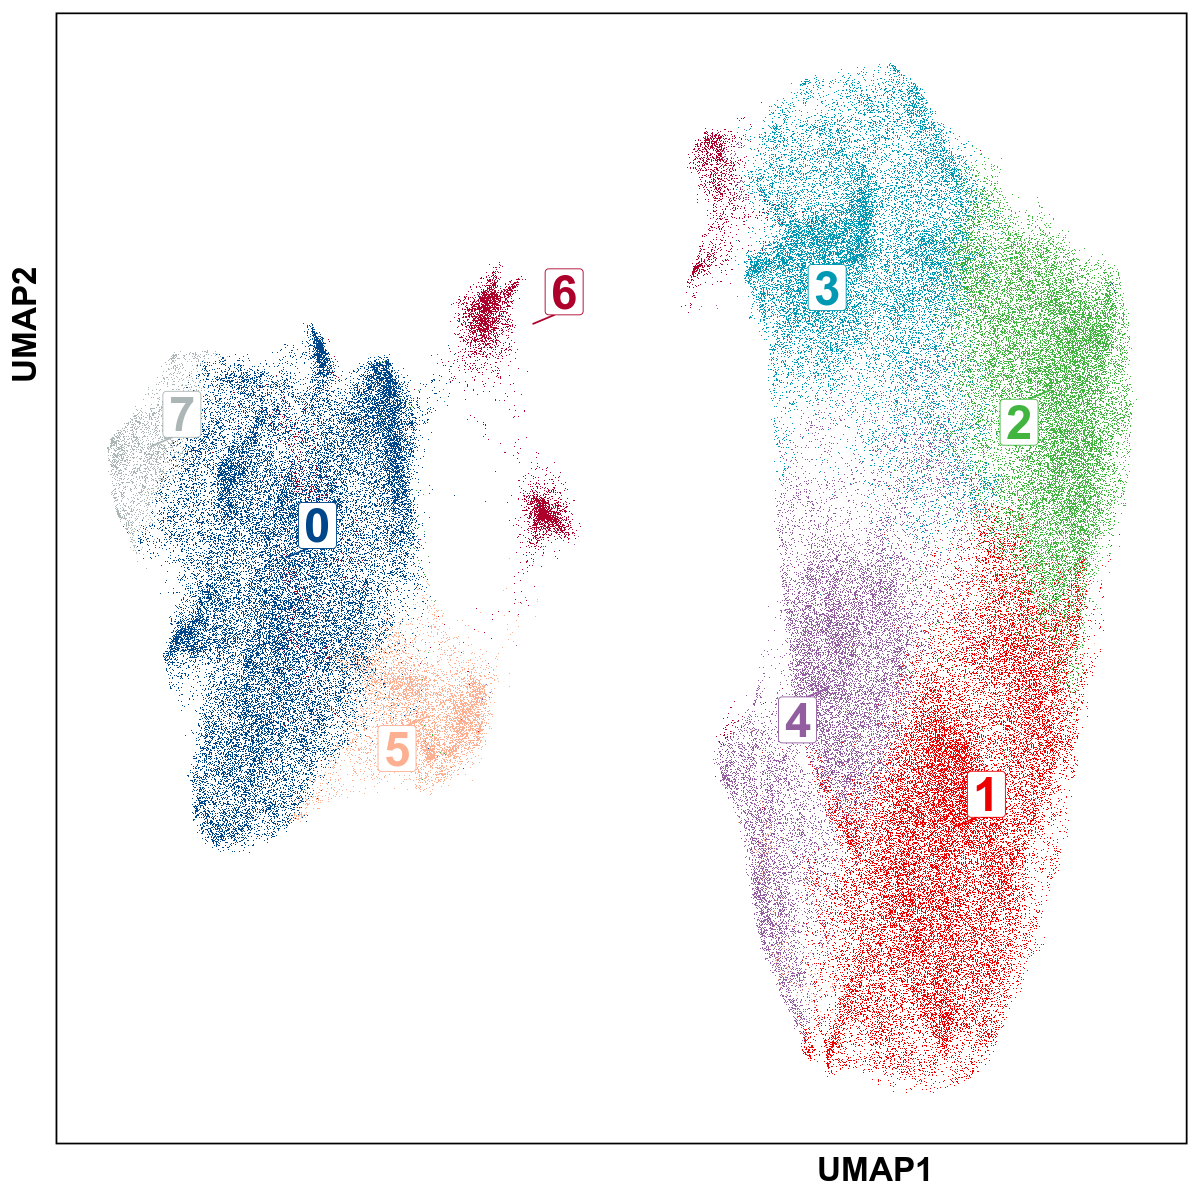

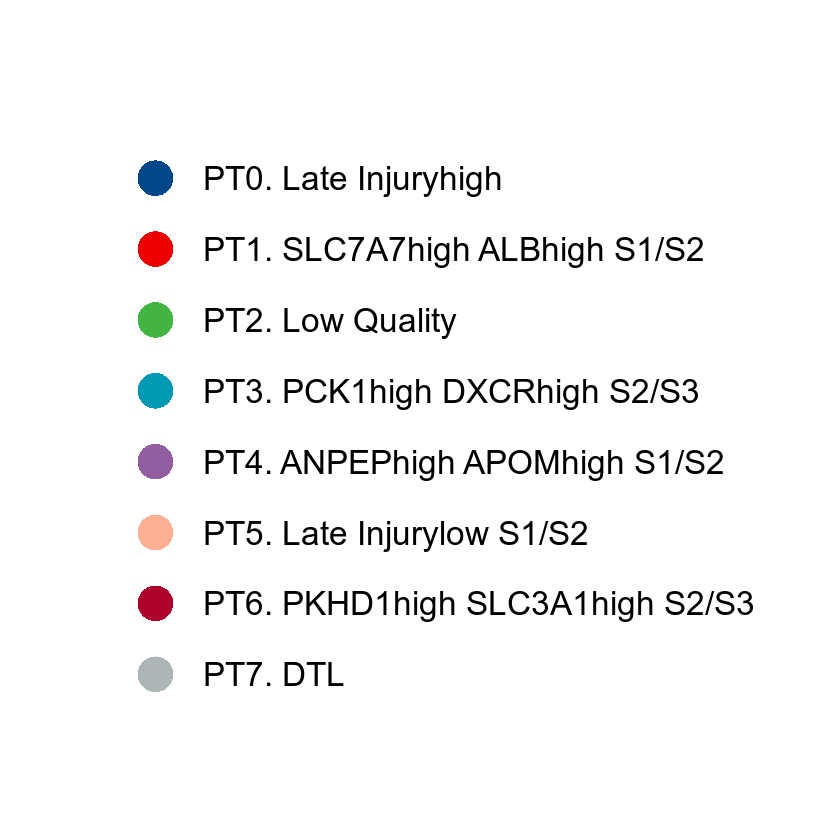

In [16]:
options(warn=-1)
cluster_center <- pt_meta %>%
                  group_by(hres.0.4, final_annotation) %>%
                  summarise_at(vars(huwotUMAP1, huwotUMAP2), funs(median(., na.rm=TRUE)))
cluster_center <- as.data.frame(cluster_center)

options(repr.plot.height = 9, repr.plot.width = 18)
p <- ggplot() +
      geom_point(
       data = pt_meta[sample(nrow(pt_meta)), ] %>% 
      select(huwotUMAP1, huwotUMAP2, final_annotation, hres.0.4) %>% 
              mutate(hres.0.4 = as.factor(hres.0.4)),
        aes(x = huwotUMAP1, y = huwotUMAP2, color = final_annotation),
          size = 0.25, shape = 20, stroke = 0.0001) +
      ggrepel::geom_label_repel(
        data = cluster_center,
        aes(x = huwotUMAP1, y = huwotUMAP2, 
            label = hres.0.4, color = as.factor(final_annotation)),
        size = 10,  fontface = "bold",
        box.padding = unit(0.5, "lines"),
        point.padding = unit(0.01, "lines"),
        show.legend = FALSE
      ) +
    ggsci::scale_color_lancet()   +
    theme_classic(base_size = 15) +
      theme(
        legend.position = "right",
            #  plot.title = element_text(hjust = 0.5, 
            #                            size = 18, 
            #                            face = "bold"),
              axis.title = element_text(hjust = 0.75, 
                                        size = 20, 
                                        face = "bold"), 
              axis.text = element_blank(),
              axis.line = element_blank(),
              axis.ticks = element_blank(),
              panel.border = element_rect(colour = "black", fill=NA, size=1),
              legend.text = element_text(size = 20),
              legend.title = element_blank()
          
    ) +
    theme(text=element_text(family="Arial")) + 
        labs(x = "UMAP1", y = "UMAP2") +
        guides(color = guide_legend(ncol = 1, override.aes = list(size = 15)))
legend <- cowplot::get_legend(p)
p <- p + theme(legend.position = "none")
legend <- cowplot::plot_grid(legend)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/figure2/figure2d.png",
       p,
       base_height = 10,
       base_width = 10)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/figure2/figure2d-legend.png",
       legend,
       base_height = 7,
       base_width = 7)
fig.size(10, 10)
p
fig.size(7, 7)
legend
options(warn=0)

In [ ]:
fig.size(10, 12)
plot_shuffled_features(pt_meta, 
                       norm, "CUBN", pct = 0.95, pt_size = 0.1)

In [ ]:
fig.size(8, 8)

plot_dist <- function(input_df, norm, feature)  {
    plot_df <- input_df %>% mutate(Exp = norm[feature, input_df$cell])
    p <- ggplot(plot_df, aes(x = hres.0.4, y = Exp, fill = dataset)) + 
            geom_violin(scale = "width") + 
            theme_classic(base_size = 20) + 
            labs(x = "Cluster", y = "Normalized Expression", title = feature) +
            theme(plot.title = element_text(size = 25, face = "bold.italic", hjust = 0.5))
    return(p)
}

In [ ]:
plot_dist(pt_meta, norm, "MOGAT1")
plot_dist(pt_meta, norm, "ABCC3")
plot_dist(pt_meta, norm, "SATB2")

In [ ]:
plot_dist(pt_meta, norm, "VCAM1")
plot_dist(pt_meta, norm, "TPM1")
plot_dist(pt_meta, norm, "DCDC2")

In [ ]:
plot_dist(pt_meta, norm, "ALDOB")
plot_dist(pt_meta, norm, "GATM")
plot_dist(pt_meta, norm, "APOE")

In [ ]:
#Pan DTL Markers 
#SATB2, JAG1, ADGRL3, ID1
plot_dist(pt_meta, norm, "JAG1")
plot_dist(pt_meta, norm, "TACSTD2")
plot_dist(pt_meta, norm, "ADGRL3")

In [ ]:
ggplot(pt_meta, 
       aes(x = as.factor(hres.0.4), y = as.numeric(doublet_score), fill = dataset)) + 
    geom_boxplot() + theme_classic(base_size = 20) + 
    labs(x = "cluster", y = "scrublet_score")




ggplot(pt_meta, 
       aes(x = as.factor(hres.0.4), y = log(as.numeric(nCount_RNA)), fill = dataset)) + 
    geom_boxplot() + theme_classic(base_size = 20) +
    labs(x = "cluster", y = "log(Counts Per Cell)")






ggplot(pt_meta,
       aes(x = as.factor(hres.0.4), y = log(as.numeric(nFeature_RNA)), fill = dataset)) + 
    geom_boxplot() + theme_classic(base_size = 20) + 
    labs(x = "cluster", y = "log(Genes Per Cell)")



In [ ]:
sc_meta <- pt_meta %>% filter(dataset == "scRNAseq")
sc_de <- wilcoxauc(norm[, sc_meta$cell], sc_meta$hres.0.4)
sn_meta <- pt_meta %>% filter(dataset == "snRNAseq")
sn_de <- wilcoxauc(norm[, sn_meta$cell], sn_meta$hres.0.4)

In [ ]:
#CRYAB, TACSTD2, SLC44A5, KLRG2, COL26A1, BOC
fig.size(10, 12)
plot_shuffled_features(pt_meta, 
                       norm, 
                       "MOGAT1", pct = 0.95) 

### SC vs SN Heatmap

In [1]:
pt_norm <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/PT_qcd_norm_12072023.rds')
pt_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/pt_meta_qcd_harmony_umap_clusternames_11302023.rds')

In [10]:
final_annotation <- data.frame(hres.0.4 = as.factor(seq(0, 7)),
                               final_annotation = c("PT0. Late Injuryhigh",
                                                    "PT1. SLC7A7high ALBhigh S1/S2",
                                                    "PT2. Low Quality",
                                                    "PT3. PCK1high DXCRhigh S2/S3",
                                                    "PT4. ANPEPhigh APOMhigh S1/S2",
                                                    "PT5. Late Injurylow S1/S2",
                                                    "PT6. PKHD1high SLC3A1high S2/S3",
                                                    "PT7. DTL"))

pt_meta <- pt_meta %>% left_join(final_annotation)

Joining, by = "hres.0.4"


In [ ]:
sc_meta <- pt_meta %>% filter(dataset == "scRNAseq")
sc_de <- wilcoxauc(pt_norm[, sc_meta$cell], sc_meta$final_annotation)

In [ ]:
sn_meta <- pt_meta %>% filter(dataset == "snRNAseq")
sn_de <- wilcoxauc(norm[, sn_meta$cell], sn_meta$final_annotation)

In [ ]:
genes <-  c("VCAM1", "TPM1", "DCDC2",
            "PRODH2", "SLC5A2", "PCK1", "DCXR",
            "SLC22A8", "SLC7A7",  "ALB",
            "ANPEP", "APOM", "SLC34A1", "SLC22A7",
             "MOGAT1", "ABCC3", "SATB2",  
             "PKHD1", "SLC3A1",   
             "JAG1", "TACSTD2")

In [ ]:
sc_plot_df <- sc_de %>%  filter(feature %in% genes) %>% 
                    select(group, feature, 
                           logFC, avgExpr, pct_in) %>% ungroup() %>% group_by(feature) %>% 
                    mutate(avgExpr_scaled = scale(avgExpr)) 
sn_plot_df <- sn_de %>%  filter(feature %in% genes) %>% 
                    select(group, feature, 
                           logFC, avgExpr, pct_in) %>% ungroup() %>% group_by(feature) %>% 
                    mutate(avgExpr_scaled = scale(avgExpr)) 

In [ ]:
fig.size(10, 15)
ggplot(sc_plot_df %>% rename(percent = pct_in,
                             zscore = avgExpr_scaled), 
               aes(x = feature, y = group, 
                   fill = zscore)) + 
    geom_tile() + 
    theme_classic(base_size = 12) + 
    scale_fill_gradient2(low = "blue",
                         mid = "white",
                         high= "red", 
                         limits=c(-2, 2), 
                         oob = scales::squish) + 
    scale_x_discrete(limits = genes) + 
    scale_y_discrete(limits = final_annotation$final_annotation) + 
    theme(axis.text.x = element_text(angle = 90),
          axis.text = element_text(face = "bold", size = 15),
          axis.title = element_text(size = 15)) + 
    labs(x = "", y = "")
fig.size(10, 15)
ggplot(sn_plot_df %>% rename(percent = pct_in,
                             zscore = avgExpr_scaled), 
               aes(x = feature, y = group, 
                   fill = zscore)) + 
    geom_tile() + 
    theme_classic(base_size = 12) + 
    scale_fill_gradient2(low = "blue",
                         mid = "white",
                         high= "red", 
                         limits=c(-2, 2), 
                         oob = scales::squish) + 
    scale_x_discrete(limits = genes) + 
    scale_y_discrete(limits = final_annotation$final_annotation) + 
    theme(axis.text.x = element_text(angle = 90),
          axis.text = element_text(face = "bold", size = 15),
          axis.title = element_text(size = 15)) + 
    labs(x = "", y = "")

In [11]:
wilcox <- wilcoxauc(pt_norm[, pt_meta$cell], pt_meta$final_annotation)

In [22]:
marker.genes <-  c("VCAM1", "TPM1", "DCDC2",
                    "PRODH2", "SLC22A8", "SLC7A7",  "ALB", "SLC5A2", "PCK1", "DCXR",
                    "ANPEP", "APOM", "SLC34A1", "SLC22A7",
                     "MOGAT1", "ABCC3", "SATB2",  
                     "PKHD1", "SLC3A1",   
                     "JAG1", "TACSTD2")

annotation.order = c("PT0. Late Injuryhigh",
                                                    "PT1. SLC7A7high ALBhigh S1/S2",
                                                    "PT2. Low Quality",
                                                    "PT3. PCK1high DXCRhigh S2/S3",
                                                    "PT4. ANPEPhigh APOMhigh S1/S2",
                                                    "PT5. Late Injurylow S1/S2",
                                                    "PT6. PKHD1high SLC3A1high S2/S3",
                                                    "PT7. DTL")

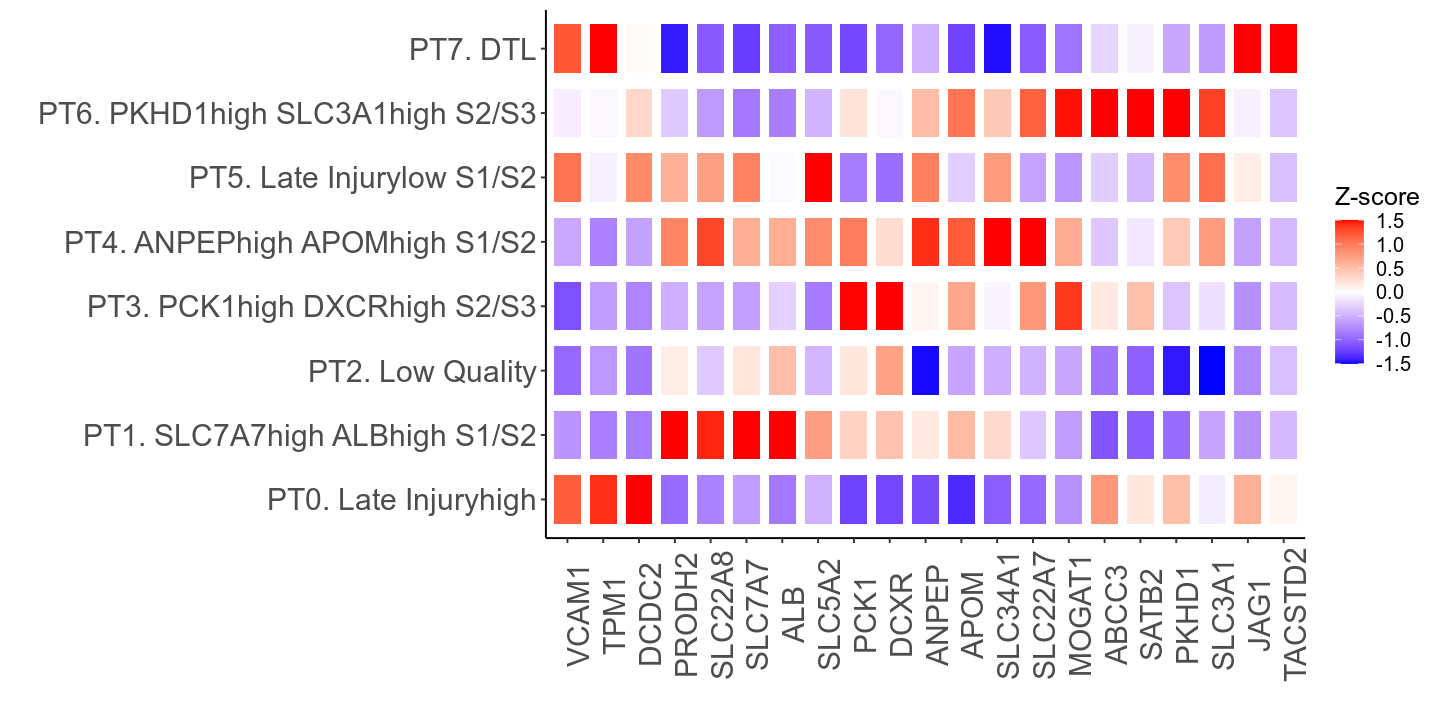

In [6]:
plot_df <- wilcox %>%  filter(feature %in% marker.genes) %>% 
                    select(group, feature, 
                           logFC, avgExpr, pct_in) %>% ungroup() %>% group_by(feature) %>% 
                    mutate(avgExpr_scaled = scale(avgExpr)) 

fig.size(6, 12)
heatmap <- ggplot(plot_df %>% rename(percent = pct_in,
                             zscore = avgExpr_scaled), 
               aes(y = group, x = feature, 
                   fill = zscore)) + 
    geom_tile(width = 0.75, height = 0.75) + 
    theme_classic(base_size = 12) + 
    scale_fill_gradient2(low = "blue",
                         mid = "white",
                         high= "red", 
                         limits=c(-1.5, 1.5), 
                         oob = scales::squish,
                         name = "Z-score") +
    scale_x_discrete(limits = marker.genes)  + 
    scale_y_discrete(limits = annotation.order) + 
    theme(axis.text.x = element_text(angle = 90),
          axis.text = element_text(size = 18),
          axis.title = element_text(size = 15),
          legend.title = element_text(size = 15),
          legend.text = element_text(size = 12)) + 
    theme(text=element_text(family="Arial")) + 
    labs(x = "", y = "")
heatmap
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/extended_data/figure1/pt.png",
       heatmap,
       base_height = 6,
       base_width = 12)

In [40]:
injury_genes_kpmp <- c(
"ITGB8", 
"CDH6", 
"DCDC2", 
"TPM1", 
"VCAM1", 
"DLGAP1", 
"ACSM3", 
"KIF26B", 
"HAVCR1")
injury_genes_aki_pnas <- c(
  "VCAM1",
  "CCL2",
  "ITGAV",
  "CD44",
  "CXCL2",
  "ZBTB7C",
  "CFTR",
  "CXCL1",
  "MALT1",
  "NFKB1"
)
injury_genes_injury_pred_nature <- c(
  "DCC",
  "DLGAP1",
  "RHEX",
  "ITGB8",
  "CDH6",
  "SEMA5A",
  "AC016383.2",
  "ROBO2",
  "CREB5",
  "CLSTN2"
)

In [42]:
length(injury_genes_injury_pred_nature)

[1] 10

In [44]:
plot_df <- wilcox %>%  filter(feature %in% injury_genes_kpmp) %>% 
                    select(group, feature, 
                           logFC, avgExpr, pct_in) %>% ungroup() %>% group_by(feature) %>% 
                    mutate(avgExpr_scaled = scale(avgExpr)) 
fig.size(6, 12)
heatmap <- ggplot(plot_df %>% rename(percent = pct_in), 
               aes(y = group, x = feature, 
                   fill = avgExpr_scaled)) + 
    geom_tile(width = 0.75, height = 0.75) + 
    theme_classic(base_size = 12) + 
    scale_fill_gradient2(low = "blue",
                         mid = "white",
                         high= "red", 
                         limits=c(-1.5, 1.5), 
                         oob = scales::squish,
                         name = "Z-score") +
    scale_x_discrete(limits = injury_genes_kpmp)  + 
    scale_y_discrete(limits = annotation.order) + 
    theme(axis.text.x = element_text(angle = 90),
          axis.text = element_text(size = 18),
          axis.title = element_text(size = 15),
          legend.title = element_text(size = 15),
          legend.text = element_text(size = 12)) + 
    theme(text=element_text(family="Arial")) + 
    labs(x = "", y = "")
heatmap
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/extended_data/figure1/pt_injury_kpmp.png",
       heatmap,
       base_height = 6,
       base_width = 12)

ERROR: Error in value[[3L]](cond): could not open file '/tmp/1631.tmpdir/Rtmp1nEZzr/file56b2232838b.png'


plot without title

In [37]:
plot_df <- wilcox %>%  filter(feature %in% injury_genes_aki_pnas) %>% 
                    select(group, feature, 
                           logFC, avgExpr, pct_in) %>% ungroup() %>% group_by(feature) %>% 
                    mutate(avgExpr_scaled = scale(avgExpr)) 
fig.size(6, 12)
heatmap <- ggplot(plot_df %>% rename(percent = pct_in), 
               aes(y = group, x = feature, 
                   fill = avgExpr_scaled)) + 
    geom_tile(width = 0.75, height = 0.75) + 
    theme_classic(base_size = 12) + 
    scale_fill_gradient2(low = "blue",
                         mid = "white",
                         high= "red", 
                         limits=c(-1.5, 1.5), 
                         oob = scales::squish,
                         name = "Z-score") +
    scale_x_discrete(limits = injury_genes_aki_pnas)  + 
    scale_y_discrete(limits = annotation.order) + 
    theme(axis.text.x = element_text(angle = 90),
          axis.text = element_text(size = 18),
          axis.title = element_text(size = 15),
          legend.title = element_text(size = 15),
          legend.text = element_text(size = 12)) + 
    theme(text=element_text(family="Arial")) + 
    labs(x = "", y = "")
heatmap
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/extended_data/figure1/pt_injury_aki_pnas.png",
       heatmap,
       base_height = 6,
       base_width = 20)

ERROR: Error in value[[3L]](cond): could not open file '/tmp/1631.tmpdir/Rtmp1nEZzr/file56b23b7e7c2.png'


plot without title

In [43]:
plot_df <- wilcox %>%  filter(feature %in% injury_genes_injury_pred_nature) %>% 
                    select(group, feature, 
                           logFC, avgExpr, pct_in) %>% ungroup() %>% group_by(feature) %>% 
                    mutate(avgExpr_scaled = scale(avgExpr)) 
fig.size(6, 12)
heatmap <- ggplot(plot_df %>% rename(percent = pct_in), 
               aes(y = group, x = feature, 
                   fill = avgExpr_scaled)) + 
    geom_tile(width = 0.75, height = 0.75) + 
    theme_classic(base_size = 12) + 
    scale_fill_gradient2(low = "blue",
                         mid = "white",
                         high= "red", 
                         limits=c(-1.5, 1.5), 
                         oob = scales::squish,
                         name = "Z-score") +
    scale_x_discrete(limits = injury_genes_injury_pred_nature)  + 
    scale_y_discrete(limits = annotation.order) + 
    theme(axis.text.x = element_text(angle = 90),
          axis.text = element_text(size = 18),
          axis.title = element_text(size = 15),
          legend.title = element_text(size = 15),
          legend.text = element_text(size = 12)) + 
    theme(text=element_text(family="Arial")) + 
    labs(x = "", y = "")
heatmap
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/extended_data/figure1/pt_injury_pred_nature.png",
       heatmap,
       base_height = 6,
       base_width = 12)

ERROR: Error in value[[3L]](cond): could not open file '/tmp/1631.tmpdir/Rtmp1nEZzr/file56b2d7a29bd.png'


plot without title

In [33]:
wilcox %>% 
    filter(group == "PT0. Late Injuryhigh") %>% 
    filter(feature %in% injury_genes_injury_pred_nature)

feature,group,avgExpr,logFC,statistic,auc,pval,padj,pct_in,pct_out
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CLIC4,PT0. Late Injuryhigh,1.1324109,-0.16105418,3786412925,0.4420713,0.000000e+00,0.000000e+00,73.013911,71.321263
RHEX,PT0. Late Injuryhigh,0.6736973,0.46815852,5371709780,0.6271579,0.000000e+00,0.000000e+00,40.415483,16.138157
SULT1C4,PT0. Late Injuryhigh,0.6329033,0.50204252,6015767586,0.7023530,0.000000e+00,0.000000e+00,52.236080,14.245395
FMNL2,PT0. Late Injuryhigh,0.5298994,0.18732865,4895474565,0.5715565,0.000000e+00,0.000000e+00,40.773403,26.009505
SATB2,PT0. Late Injuryhigh,0.2906816,0.10021104,4676864688,0.5460334,0.000000e+00,0.000000e+00,26.425224,17.101308
ROBO2,PT0. Late Injuryhigh,0.1271584,0.11411671,4510329199,0.5265900,0.000000e+00,0.000000e+00,6.555109,1.277662
CLSTN2,PT0. Late Injuryhigh,0.4544203,0.30666290,5127203697,0.5986114,0.000000e+00,0.000000e+00,31.519132,12.327319
TNIK,PT0. Late Injuryhigh,0.5750208,0.24562385,5057021814,0.5904175,0.000000e+00,0.000000e+00,44.339692,26.411978
SLC2A9,PT0. Late Injuryhigh,0.4714016,-0.06502167,4294467928,0.5013878,2.483461e-01,3.211460e-01,35.114940,32.345924


### SC vs SN Cluster Freq

In [108]:
pt_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/pt_meta_qcd_harmony_umap_clusternames_11302023.rds')

In [4]:
pt_meta <- pt_meta  %>% 
                mutate(individual = str_split(sample, '_')) %>% 
                rowwise() %>% 
                mutate(individual = unlist(individual)[3]) 

In [ ]:
sample_freq <- pt_meta %>% select(dataset, individual, hres.0.4) %>% 
                    table() %>% data.frame() %>% 
                    pivot_wider(names_from = "hres.0.4", values_from = Freq) 

In [ ]:
ind_list <- pt_meta %>% select(dataset, individual) %>% 
                table() %>% data.frame() %>% 
                pivot_wider(names_from = 'dataset', values_from = "Freq") %>% filter(scRNAseq > 200 & snRNAseq > 200) %>% 
                pull(individual)

In [ ]:
sample_freq_sc <- sample_freq %>% 
                    filter(individual %in% ind_list) %>% 
                    select(- individual) %>% 
                    filter(dataset == "scRNAseq") %>% 
                    select(-dataset) %>% colSums()

sample_freq_sn <- sample_freq %>% 
                    filter(individual %in% ind_list) %>% 
                    select(- individual) %>% 
                    filter(dataset == "snRNAseq") %>% 
                    select(-dataset) %>% colSums()

In [ ]:
sample_freq <- data.frame(rep("a", 8))
sample_freq$sc_freq <- sample_freq_sc / sum(sample_freq_sc)
sample_freq$sc_se <- sqrt((sample_freq$sc_freq * (1 - sample_freq$sc_freq)) / sample_freq_sc)
sample_freq$sn_freq <- sample_freq_sn / sum(sample_freq_sn)
sample_freq$sn_se <- sqrt((sample_freq$sn_freq * (1 - sample_freq$sn_freq)) / sample_freq_sn)
sample_freq$hres.0.4 <- as.character(seq(0, 7))
sample_freq <- sample_freq[,- 1]

In [ ]:
fig.size(8, 8)

max_val <- max(sample_freq[, c("sc_freq", "sn_freq")])

ggplot(sample_freq, aes(x = sc_freq, y = sn_freq, color = hres.0.4)) + 
    geom_abline(linetype = "dashed") +
    ggsci::scale_color_lancet()   +
    theme_classic() + 
    geom_point(size = 4) + 
    geom_linerange(aes(ymax = sn_freq+1.96*sn_se, 
                        ymin = sn_freq-1.96*sn_se), alpha = 0.5) +
    geom_linerange(aes(xmax = sc_freq+1.96*sc_se, 
                        xmin = sc_freq-1.96*sc_se), alpha = 0.5) +
    theme(legend.position = "none",
          axis.text = element_text(size = 15),
          axis.title = element_text(size = 18)) +
    coord_cartesian(xlim = c(0, 0.25), ylim = c(0, 0.25)) + 
    labs(x = "scRNAseq",
         y = "snRNAseq")

In [ ]:
cor.test(sample_freq$sc_freq, sample_freq$sn_freq)

In [67]:
lateinjury_high_prop <- pt_meta %>% 
                filter(dataset == 'scRNAseq') %>% 
                select(sample, final_annotation) %>% 
                table() %>% data.frame() %>% 
                group_by(sample) %>% mutate(Prop = Freq / sum(Freq)) %>% 
                filter(final_annotation == "PT0. Late Injuryhigh")
saveRDS(lateinjury_high_prop, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/injured_pt_highprop_singlecell_05102024.rds')
lateinjury_low_prop <- pt_meta %>% 
                filter(dataset == 'scRNAseq') %>% 
                select(sample, final_annotation) %>% 
                table() %>% data.frame() %>% 
                group_by(sample) %>% mutate(Prop = Freq / sum(Freq)) %>% 
                filter(final_annotation == "PT5. Late Injurylow S1/S2")
saveRDS(lateinjury_low_prop, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/injured_pt_lowprop_singlecell_05102024.rds')

In [333]:
lateinjury_high_prop <- pt_meta %>% 
                filter(dataset == 'snRNAseq') %>% 
                select(sample, final_annotation) %>% 
                table() %>% data.frame() %>% 
                group_by(sample) %>% mutate(Prop = Freq / sum(Freq)) %>% 
                filter(final_annotation == "PT0. Late Injuryhigh")
saveRDS(lateinjury_high_prop, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/injured_pt_highprop_singlenuc_05102024.rds')
lateinjury_low_prop <- pt_meta %>% 
                filter(dataset == 'snRNAseq') %>% 
                select(sample, final_annotation) %>% 
                table() %>% data.frame() %>% 
                group_by(sample) %>% mutate(Prop = Freq / sum(Freq)) %>% 
                filter(final_annotation == "PT5. Late Injurylow S1/S2")
saveRDS(lateinjury_low_prop, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/injured_pt_lowprop_singlenuc_05102024.rds')


	Pearson's product-moment correlation

data:  plot_df$scRNAseq and plot_df$snRNAseq
t = 6.1665, df = 48, p-value = 1.395e-07
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.4742731 0.7959087
sample estimates:
      cor 
0.6648519 



	Pearson's product-moment correlation

data:  plot_df$scRNAseq and plot_df$snRNAseq
t = 3.3023, df = 48, p-value = 0.001816
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.1725879 0.6328243
sample estimates:
      cor 
0.4302659 



	Pearson's product-moment correlation

data:  plot_df$scRNAseq and plot_df$snRNAseq
t = 3.3023, df = 48, p-value = 0.001816
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.1725879 0.6328243
sample estimates:
      cor 
0.4302659 


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


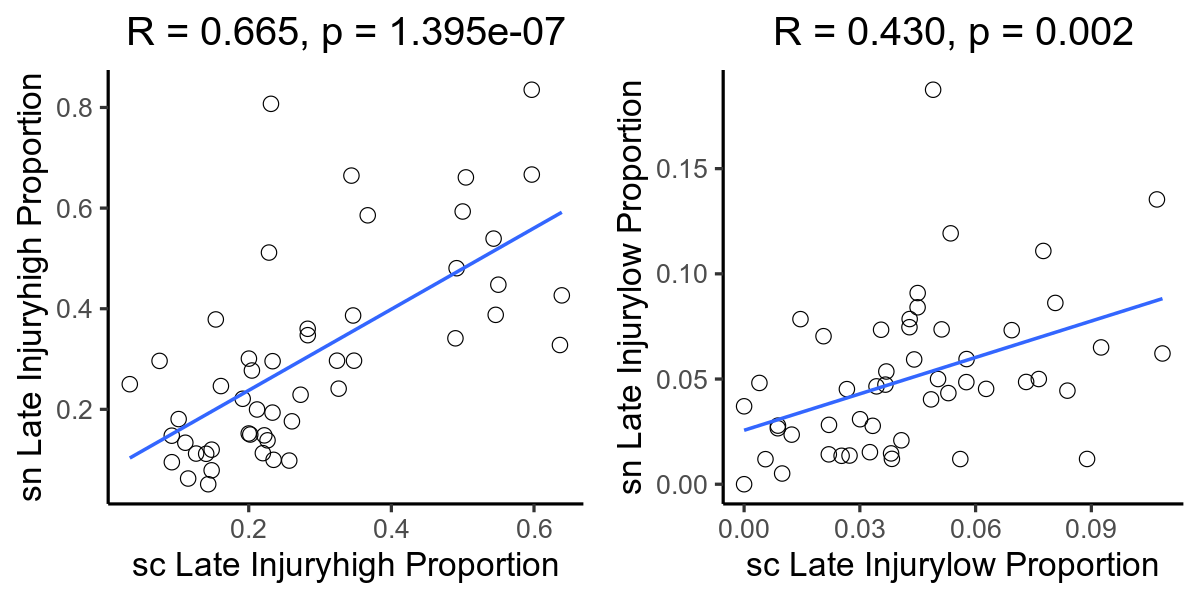

In [136]:
sn_list <- pt_meta %>% 
                filter(dataset == 'snRNAseq') %>% 
                pull(individual) %>% unique()
plot_df <- pt_meta %>% 
                select(individual, dataset, final_annotation) %>% 
                table() %>% data.frame() %>% 
                group_by(individual, dataset) %>% 
                mutate(Prop = Freq / sum(Freq)) %>% 
                filter(final_annotation == 'PT0. Late Injuryhigh') %>% 
                mutate(Prop = ifelse(is.na(Prop), 0, Prop)) %>% 
                select(individual, dataset, Prop) %>% 
                pivot_wider(names_from = 'dataset',
                            values_from = 'Prop')  %>% 
                filter(individual %in% sn_list)

cor.test(plot_df$scRNAseq, plot_df$snRNAseq)

p1 <- ggplot(plot_df, 
           aes(x = scRNAseq, y = snRNAseq)) +
    geom_point(shape = 21, size = 4) + 
    theme_classic(base_size = 20) + 
    geom_smooth(method = 'lm', se = FALSE) + 
    labs(x = 'sc Late Injuryhigh Proportion', 
         y = 'sn Late Injuryhigh Proportion',
         title = 'R = 0.665, p = 1.395e-07') + 
    theme(plot.title = element_text(hjust = 0.5))


plot_df <- pt_meta %>% 
                select(individual, dataset, final_annotation) %>% 
                table() %>% data.frame() %>% 
                group_by(individual, dataset) %>% 
                mutate(Prop = Freq / sum(Freq)) %>% 
                filter(final_annotation == "PT5. Late Injurylow S1/S2") %>% 
                mutate(Prop = ifelse(is.na(Prop), 0, Prop)) %>% 
                select(individual, dataset, Prop) %>% 
                pivot_wider(names_from = 'dataset',
                            values_from = 'Prop')  %>% 
                filter(individual %in% sn_list)

cor.test(plot_df$scRNAseq, plot_df$snRNAseq)

cor.test(plot_df$scRNAseq, plot_df$snRNAseq)

p2 <- ggplot(plot_df, 
           aes(x = scRNAseq, y = snRNAseq)) +
    geom_point(shape = 21, size = 4) + 
    theme_classic(base_size = 20) + 
    geom_smooth(method = 'lm', se = FALSE) + 
    labs(x = 'sc Late Injurylow Proportion', 
         y = 'sn Late Injurylow Proportion',
         title = 'R = 0.430, p = 0.002') + 
    theme(plot.title = element_text(hjust = 0.5))
cowplot::plot_grid(p1, p2)


	Pearson's product-moment correlation

data:  plot_df$LateInjuryHigh and plot_df$LateInjuryLow
t = 5.2198, df = 183, p-value = 4.83e-07
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.2275377 0.4793620
sample estimates:
      cor 
0.3599891 


`geom_smooth()` using formula = 'y ~ x'


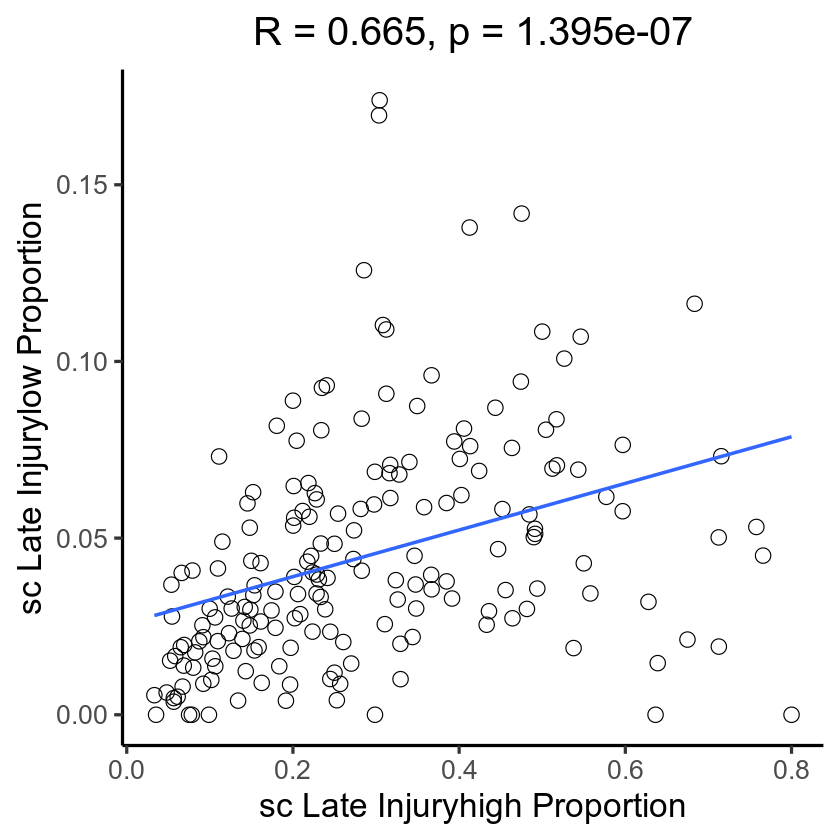

In [44]:
plot_df <- pt_meta %>% filter(dataset == 'scRNAseq') %>% 
                select(individual, final_annotation) %>% 
                table() %>% data.frame() %>% 
                group_by(individual) %>% 
                mutate(Prop = Freq / sum(Freq)) %>% 
                filter(final_annotation %in% c('PT0. Late Injuryhigh',
                                               "PT5. Late Injurylow S1/S2")) %>% 
                mutate(Prop = ifelse(is.na(Prop), 0, Prop)) %>% 
                select(individual, final_annotation, Prop) %>% 
                pivot_wider(names_from = 'final_annotation',
                            values_from = 'Prop')
colnames(plot_df) <- c("individual", "LateInjuryHigh", "LateInjuryLow")

cor.test(plot_df$LateInjuryHigh, plot_df$LateInjuryLow)

ggplot(plot_df, 
           aes(x = LateInjuryHigh, y = LateInjuryLow)) +
    geom_point(shape = 21, size = 4) + 
    theme_classic(base_size = 20) + 
    geom_smooth(method = 'lm', se = FALSE) + 
    labs(x = 'sc Late Injuryhigh Proportion', 
         y = 'sc Late Injurylow Proportion',
         title = 'R = 0.360, p = 4.83e-07') + 
    theme(plot.title = element_text(hjust = 0.5))

## CASE/CONTROL

In [3]:
pt_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/pt_meta_qcd_harmony_umap_clusternames_11302023.rds')

final_annotation <- data.frame(hres.0.4 = as.factor(seq(0, 7)),
                               final_annotation = c("PT0. Late Injuryhigh",
                                                    "PT1. SLC7A7high ALBhigh S1/S2",
                                                    "PT2. Low Quality",
                                                    "PT3. PCK1high DXCRhigh S2/S3",
                                                    "PT4. ANPEPhigh APOMhigh S1/S2",
                                                    "PT5. Late Injurylow S1/S2",
                                                    "PT6. PKHD1high SLC3A1high S2/S3",
                                                    "PT7. DTL"))
pt_meta <- pt_meta %>% left_join(final_annotation)

Joining, by = "hres.0.4"


In [7]:
sc_meta <- pt_meta[, !colnames(pt_meta) %in% colnames(clinical)] %>% 
                        mutate(kid_sample = pt_meta$sample) %>% 
                        filter(dataset == 'scRNAseq') %>% 
                        mutate(individual = str_split(kid_sample, '_')) %>% 
                        rowwise() %>% 
                        mutate(individual = unlist(individual)[3]) %>% 
                        left_join(clinical %>% select(Final_Site, Age, Sex, Type, individual))

meta <- sc_meta %>% select(-c(colnames(sc_meta[grep('hPC', colnames(sc_meta))]), 
                          colnames(sc_meta[grep('UMAP', colnames(sc_meta))])))
harmony <- sc_meta %>% select(colnames(sc_meta)[grep('hPC', colnames(sc_meta))])

umap <- sc_meta %>% select(c(huwotUMAP1, huwotUMAP2))

ind <- c(1:nrow(meta))[!is.na(meta$Type)]

meta <- meta[ind, ]
umap <- umap[ind, ]
harmony <- harmony[ind, ]

meta <- meta %>% mutate(Type_numeric = ifelse(Type == "LN", 1, 0))


write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/case_control/sc_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/case_control/sc_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/case_control/sc_umap.csv', 
          row.names = FALSE, quote = FALSE)

sn_meta <- pt_meta[, !colnames(pt_meta) %in% colnames(clinical)] %>% 
                        mutate(kid_sample = pt_meta$sample) %>% 
                        filter(dataset == 'snRNAseq') %>% 
                        mutate(individual = str_split(kid_sample, '_')) %>% 
                        rowwise() %>% 
                        mutate(individual = unlist(individual)[3]) %>% 
                        left_join(clinical %>% select(Final_Site, Age, Sex, Type, individual))

meta <- sn_meta %>% select(-c(colnames(sc_meta[grep('hPC', colnames(sc_meta))]), 
                          colnames(sc_meta[grep('UMAP', colnames(sc_meta))])))
harmony <- sn_meta %>% select(colnames(sc_meta)[grep('hPC', colnames(sc_meta))])

umap <- sn_meta %>% select(c(huwotUMAP1, huwotUMAP2))

ind <- c(1:nrow(meta))[!is.na(meta$Type)]

meta <- meta[ind, ]
umap <- umap[ind, ]
harmony <- harmony[ind, ]

meta <- meta %>% mutate(Type_numeric = ifelse(Type == "LN", 1, 0))


write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/case_control/sn_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/case_control/sn_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/case_control/sn_umap.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "individual"
Joining, by = "individual"


### DE

In [ ]:
pt_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/pt_meta_qcd_harmony_umap_clusternames_11302023.rds')
pt_norm <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/PT_qcd_norm_12072023.rds')

In [ ]:
out <- mclapply(unique(pt_meta$sample), pseudobulk, pt_meta, pt_norm,
               mc.cores = 6)
pt_pb <- data.frame(do.call(rbind, out))

In [ ]:
sample_stats <- pt_meta %>% group_by(sample) %>% summarize(avg_count = mean(nCount_RNA), avg_mt = mean(percent.mt))
pt_pb <- pt_pb %>% left_join(sample_stats) %>% left_join(unique(pt_meta %>% select(sample, Type)))
pt_pb <- pt_pb[grep("cells", pt_pb$sample), ]
colnames(pt_pb)[1:36601] <- rownames(pt_norm)

In [ ]:
saveRDS(pt_pb, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/PT_norm_pseudobulk_12072023.rds')

In [ ]:
pt_pb <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/PT_norm_pseudobulk_12072023.rds')

In [ ]:
de_out <- mclapply(colnames(pt_pb)[1:36601], de, pt_pb, mc.cores = 20)

In [ ]:
de_df <- data.frame(do.call(rbind, de_out)) %>% mutate(LRP = as.numeric(LRP),
                                                       F = as.numeric(F),
                                                       Beta = as.numeric(Beta),
                                                       SE = as.numeric(SE))

In [ ]:
saveRDS(de_df, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/PT_case_control_differential_expression_120722023.rds')

In [ ]:
de_df <- de_df %>% na.omit()

In [ ]:
genes <- c('FKBP5', 'ZBTB16', 'PDK4', 'KLF6',
           'B2M', 'SPP1', 'NAT8', 'IFI27', 'IFI6')

In [ ]:
fig.size(6, 6)
ggplot(de_df,
                aes(x = Beta, y = -log10(LRP))) +
    geom_point(colour = 'lightgrey') + 
    geom_point(data = de_df %>% filter(LRP < 0.05/nrow(de_df) & abs(Beta) >= 0.3,
                                        ! gene %in% genes),
                   aes(x = Beta, y = -log10(LRP)),  color = "blue", size = 1) +
    geom_point(data = de_df %>% filter(gene %in% genes),
                   aes(x = Beta, y = -log10(LRP)),  color = "blue", size = 3)  + 
    geom_vline(xintercept = c(-0.3, 0.3), linetype = "dashed") + 
    geom_hline(yintercept = -log10(0.05/nrow(de_df)), linetype = "dashed") + 
    theme_classic() + 
    theme(legend.position = "none",
          axis.text = element_text(size = 15),
          axis.title = element_text(size = 18),
          plot.title = element_text(size = 25, hjust = 0.5, face = "bold")) +
    ggrepel::geom_text_repel(data = de_df %>% 
                                     mutate(label = ifelse(LRP < 0.05/nrow(de_df) & abs(Beta) >= 0.3 | 
                                                           gene %in% genes, gene, NA),
                                            label_size = ifelse(gene %in% genes, 6 , 3)),
                                     aes(x = Beta, y = -log10(LRP), 
                                         size = label_size, label = label)
            , color = "black") +
    scale_size_identity() + 
    labs(x = "Case/Control Beta", y = "-log10(Pvalue)", title = "PT")

### CNA

#### RESULTS

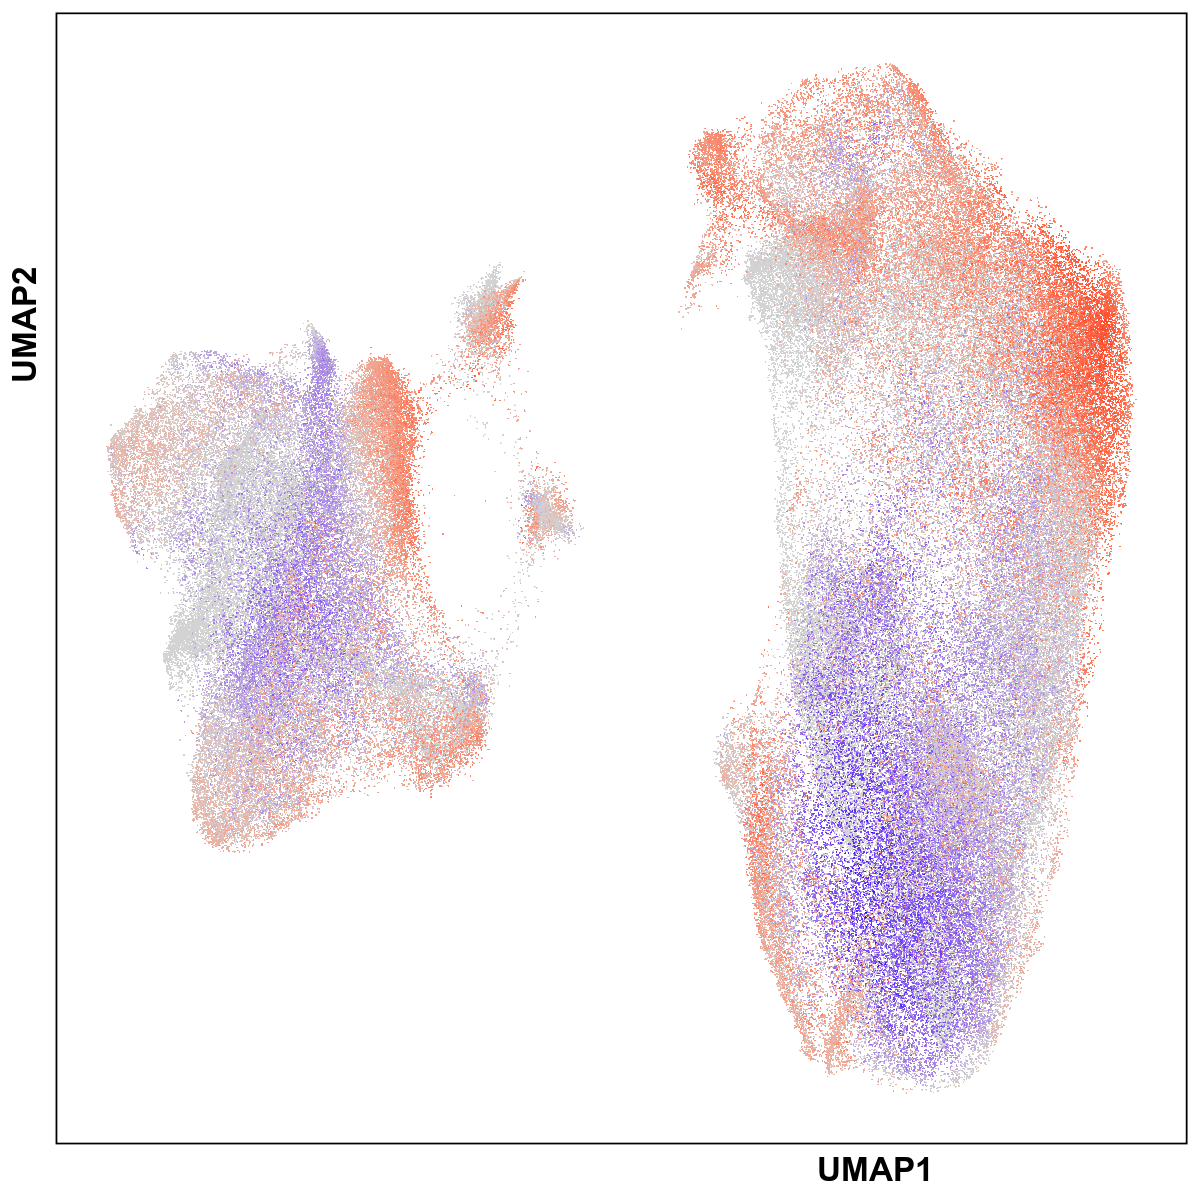

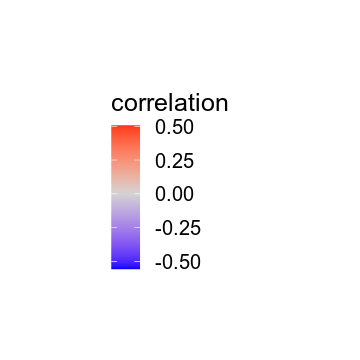

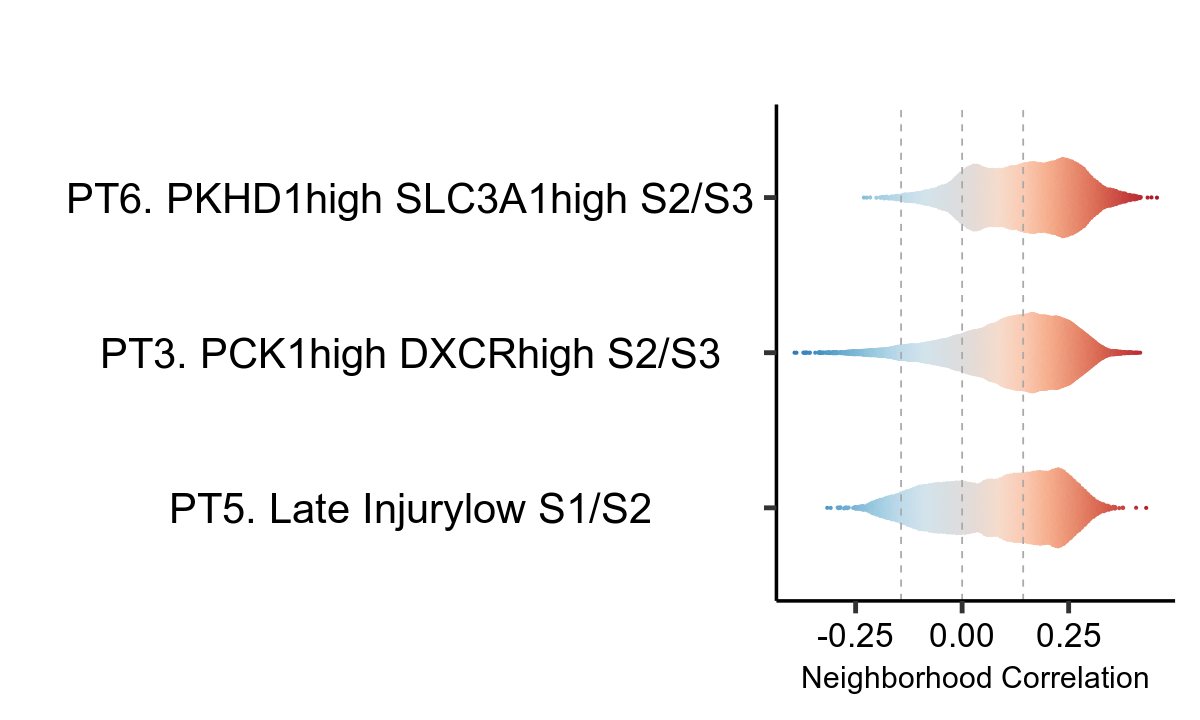

In [4]:
options(warn = -1)
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/case_control/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/case_control/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/case_control/sc_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/case_control/sc_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1

fdr <- fdrs %>% filter(fdr < 0.05) %>% 
            mutate(fdr = round(fdr, 4)) %>% 
            filter(fdr == max(fdr)) %>% 
            pull(threshold)

tmp_meta <- meta %>% mutate(ifelse(abs(meta$ncorr) > fdr, ncorr, NA))
tmp_meta <- cbind(tmp_meta, umap)

fig.size(8, 8)
cna_umap <- ggplot() + 
geom_point(data = pt_meta,
                aes(x = huwotUMAP1, y = huwotUMAP2), color = 'lightgrey', size = 0.75, stroke = 0.0001, shape = 20) + 
      geom_point(
      data = tmp_meta[sample(nrow(tmp_meta)),] %>% rename(correlation = ncorr), 
          aes(x = huwotUMAP1, y = huwotUMAP2, color = correlation), size = 0.75, stroke = 0.0001, shape = 20) + 
      scale_color_gradient2(low = 'blue', mid = 'lightgray', high = 'red', na.value = "lightgrey") + 
     # labs(x="UMAP1", y="UMAP2", title = "Myeloid Chronicity: p = 2.00e-04") +
theme_classic(base_size = 15) +
      theme(
        legend.position = "right",
            #  plot.title = element_text(hjust = 0.5, 
            #                            size = 18, 
            #                            face = "bold"),
              axis.title = element_text(hjust = 0.75, 
                                        size = 20, 
                                        face = "bold"), 
              axis.text = element_blank(),
              axis.line = element_blank(),
              axis.ticks = element_blank(),
              panel.border = element_rect(colour = "black", fill=NA, size=1)
    ) +
        labs(x = "UMAP1", y = "UMAP2") + 
    theme(text=element_text(family="Arial")) 

umap_legend <- cowplot::get_legend(cna_umap)
cna_umap <- cna_umap + theme(legend.position = "none")
umap_legend <- cowplot::plot_grid(umap_legend)
fig.size(10, 10)
cna_umap
fig.size(3, 3)
umap_legend

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure3/pt_sc_cna_umap.png",
       cna_umap,
       base_height = 10,
       base_width = 10)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure3/pt_sc_cna_umap_legend.png",
       umap_legend,
       base_height = 3,
       base_width = 3)

pos_fdr_thresh <- fdr
neg_fdr_thresh <- -1 * fdr


interval <- c(-max(abs(meta$ncorr)), max(abs(meta$ncorr)))
myPalette <- colorRampPalette(c(RColorBrewer::brewer.pal(11, "RdBu")[11:7], "#DCDCDC", RColorBrewer::brewer.pal(11, "RdBu")[5:1]))

subset <- c("PT3. PCK1high DXCRhigh S2/S3", "PT5. Late Injurylow S1/S2", "PT6. PKHD1high SLC3A1high S2/S3")

violin_plot <- ggplot(meta %>% filter(final_annotation %in% subset), aes(y = reorder(final_annotation, ncorr), x = ncorr)) +
                    ggbeeswarm::geom_quasirandom(aes(color = ncorr), width = 0.25, size = 0.5) +
                    geom_vline(xintercept = neg_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                    geom_vline(xintercept = pos_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                    geom_vline(xintercept = 0, linetype = "dashed", color = "darkgrey") +
                    scale_colour_gradientn(colours = myPalette(20), limits = interval) +
                    labs( x= "Neighborhood Correlation", y = "", title = "") +
                    theme_classic(base_size = 30) +
                    theme(text=element_text(family="Arial"),
                        legend.position = "none",
                        panel.grid = element_blank(),
                        axis.text.x = element_text(color = "black", size = 20, hjust=0.5),
                        axis.text.y = element_text(color = "black", size = 25, hjust=0.5),
                        axis.title = element_text(size=18, hjust = 0.5),
                        axis.line.x.bottom = element_line(color = 'black', linewidth = 1),
                        axis.line.y.left   = element_line(color = 'black', linewidth = 1))


cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure3/pt_sc_violin_plot.png",
       violin_plot,
       base_height = 6,
       base_width = 10)
fig.size(6, 10)
violin_plot
options(warn=0)

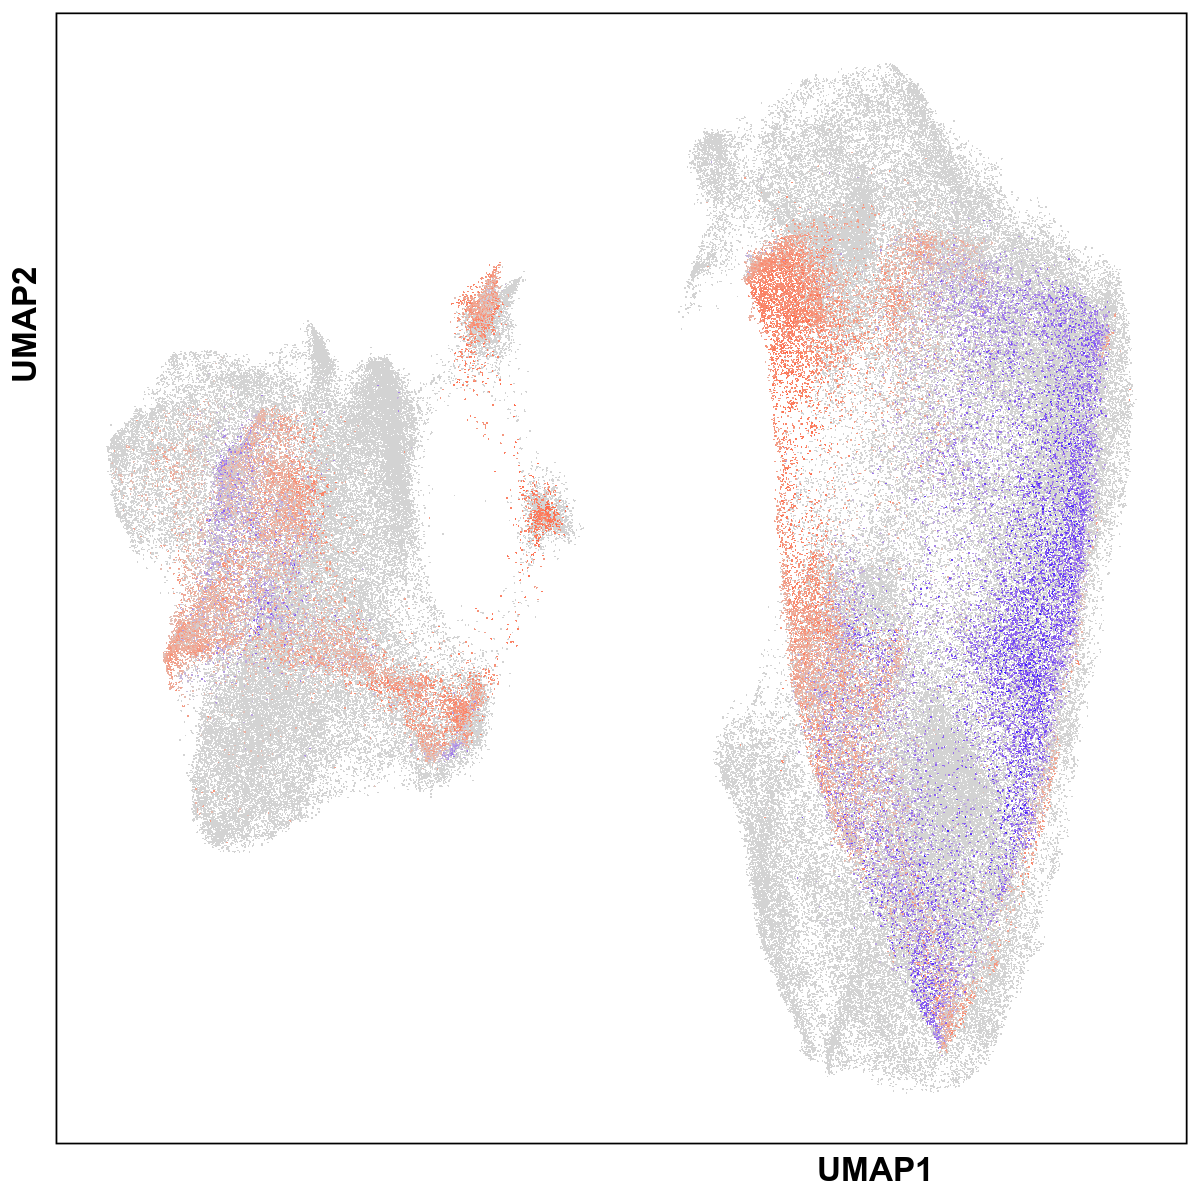

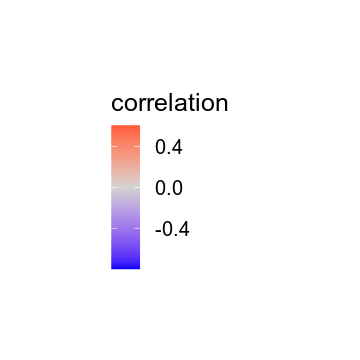

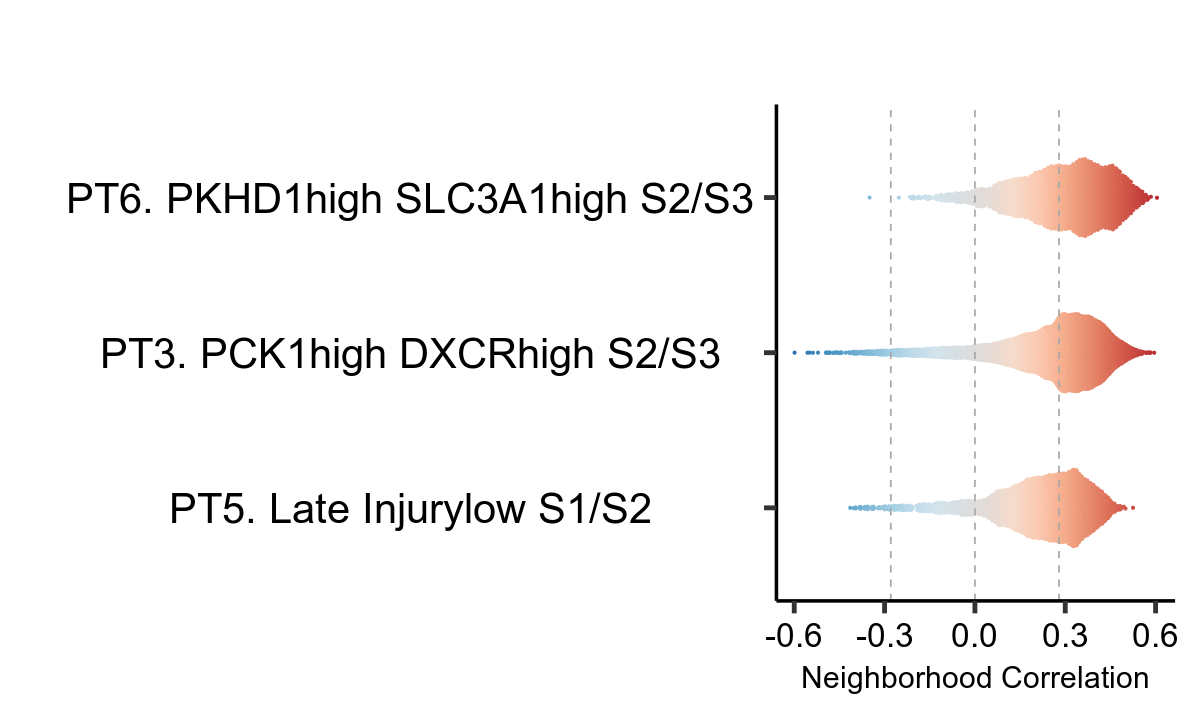

In [5]:
options(warn = -1)
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/case_control/sn_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/case_control/sn_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/case_control/sn_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/case_control/sn_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1

fdr <- fdrs %>% filter(fdr < 0.05) %>% 
            mutate(fdr = round(fdr, 4)) %>% 
            filter(fdr == max(fdr)) %>% 
            pull(threshold)

tmp_meta <- meta %>% mutate(ifelse(abs(meta$ncorr) > fdr, ncorr, NA))
tmp_meta <- cbind(tmp_meta, umap)

fig.size(8, 8)
cna_umap <- ggplot() + 
geom_point(data = pt_meta,
                aes(x = huwotUMAP1, y = huwotUMAP2), color = 'lightgrey', size = 0.75, stroke = 0.0001, shape = 20) + 
      geom_point(
      data = tmp_meta[sample(nrow(tmp_meta)),] %>% rename(correlation = ncorr), 
          aes(x = huwotUMAP1, y = huwotUMAP2, color = correlation), size = 0.75, stroke = 0.0001, shape = 20) + 
      scale_color_gradient2(low = 'blue', mid = 'lightgray', high = 'red', na.value = "lightgrey") + 
     # labs(x="UMAP1", y="UMAP2", title = "Myeloid Chronicity: p = 2.00e-04") +
theme_classic(base_size = 15) +
      theme(
        legend.position = "right",
            #  plot.title = element_text(hjust = 0.5, 
            #                            size = 18, 
            #                            face = "bold"),
              axis.title = element_text(hjust = 0.75, 
                                        size = 20, 
                                        face = "bold"), 
              axis.text = element_blank(),
              axis.line = element_blank(),
              axis.ticks = element_blank(),
              panel.border = element_rect(colour = "black", fill=NA, size=1)
    ) +
        labs(x = "UMAP1", y = "UMAP2") + 
    theme(text=element_text(family="Arial")) 

umap_legend <- cowplot::get_legend(cna_umap)
cna_umap <- cna_umap + theme(legend.position = "none")
umap_legend <- cowplot::plot_grid(umap_legend)
fig.size(10, 10)
cna_umap
fig.size(3, 3)
umap_legend

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/extended_data/figure2/pt_sn_cna_umap.png",
       cna_umap,
       base_height = 10,
       base_width = 10)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/extended_data/figure2/pt_sn_cna_umap_legend.png",
       umap_legend,
       base_height = 3,
       base_width = 3)

pos_fdr_thresh <- fdr
neg_fdr_thresh <- -1 * fdr


interval <- c(-max(abs(meta$ncorr)), max(abs(meta$ncorr)))
myPalette <- colorRampPalette(c(RColorBrewer::brewer.pal(11, "RdBu")[11:7], "#DCDCDC", RColorBrewer::brewer.pal(11, "RdBu")[5:1]))

subset <- c("PT3. PCK1high DXCRhigh S2/S3", "PT5. Late Injurylow S1/S2", "PT6. PKHD1high SLC3A1high S2/S3")

violin_plot <- ggplot(meta %>% filter(final_annotation %in% subset), aes(y = reorder(final_annotation, ncorr), x = ncorr)) +
                    ggbeeswarm::geom_quasirandom(aes(color = ncorr), width = 0.25, size = 0.5) +
                    geom_vline(xintercept = neg_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                    geom_vline(xintercept = pos_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                    geom_vline(xintercept = 0, linetype = "dashed", color = "darkgrey") +
                    scale_colour_gradientn(colours = myPalette(20), limits = interval) +
                    labs( x= "Neighborhood Correlation", y = "", title = "") +
                    theme_classic(base_size = 30) +
                    theme(text=element_text(family="Arial"),
                        legend.position = "none",
                        panel.grid = element_blank(),
                        axis.text.x = element_text(color = "black", size = 20, hjust=0.5),
                        axis.text.y = element_text(color = "black", size = 25, hjust=0.5),
                        axis.title = element_text(size=18, hjust = 0.5),
                        axis.line.x.bottom = element_line(color = 'black', linewidth = 1),
                        axis.line.y.left   = element_line(color = 'black', linewidth = 1))


cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/extended_data/figure2/pt_sn_violin_plot.png",
       violin_plot,
       base_height = 6,
       base_width = 10)
fig.size(6, 10)
violin_plot
options(warn=0)

## WITHIN CASES

In [2]:
pt_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/pt_meta_qcd_harmony_umap_clusternames_11302023.rds')

clinical <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/clinical_data_05042023.rds') %>% 
                        rename(Final_Site = Site) %>% select(-sample)

first_biop_pred <- readRDS("/data/srlab2/qxiao/AMP-SLE/data/clinical/df_pred_biop.rds") %>% 
                        mutate(individual = str_split(Subject_ID, '-')) %>% 
                        rowwise() %>% 
                        mutate(individual = unlist(individual)[2])


sc_meta <- pt_meta %>% filter(dataset == 'scRNAseq', Type == "LN") %>% 
                        select(- colnames(pt_meta)[colnames(pt_meta) %in% colnames(clinical)]) %>% 
                        mutate(individual = str_split(sample, '_')) %>% 
                        rowwise() %>% 
                        mutate(individual = unlist(individual)[3]) %>% 
                        left_join(clinical) %>% 
                        left_join(first_biop_pred) %>% 
                        select(c(cell, paste0('hPC-', 1:20), Sex, huwotUMAP1, huwotUMAP2, sample, final_annotation,
                                 Responder.Status, Age, Race, Final_ISN, Final_Chronicity, Final_Activity, Type, Final_Site,
                                 First_biop, Pred_use)) 

sn_meta <- pt_meta %>% filter(dataset == 'snRNAseq', Type == "LN") %>% 
                        select(- colnames(pt_meta)[colnames(pt_meta) %in% colnames(clinical)]) %>% 
                        mutate(individual = str_split(sample, '_')) %>% 
                        rowwise() %>% 
                        mutate(individual = unlist(individual)[3]) %>% 
                        left_join(clinical) %>% 
                        left_join(first_biop_pred) %>% 
                        select(c(cell, paste0('hPC-', 1:20), Sex, huwotUMAP1, huwotUMAP2, sample, final_annotation,
                                 Responder.Status, Age, Race, Final_ISN, Final_Chronicity, Final_Activity, Type, Final_Site,
                                 First_biop, Pred_use)) 

Joining, by = "individual"
Joining, by = "individual"


ERROR: [1m[33mError[39m in `select()`:[22m
[33m![39m Can't subset columns that don't exist.
[31m✖[39m Column `final_annotation` doesn't exist.


## RESPONSE

In [ ]:
meta <- sn_meta %>% select(-c(colnames(sn_meta[grep('hPC-', colnames(sn_meta))]), 
                          colnames(sn_meta[grep('huwotUMAP', colnames(sn_meta))])))
harmony <- sn_meta %>% select(colnames(sn_meta)[grep('hPC-', colnames(sn_meta))])

umap <- sn_meta %>% select(c(huwotUMAP1, huwotUMAP2))

ind <- c(1:nrow(meta))[which(meta$Responder.Status %in% c("NR", "CR", "PR"))]

meta <- meta[ind, ]
harmony <- harmony[ind, ]
umap <- umap[ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex <- as.numeric(as.factor(meta$Sex))
meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")



write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/age_sex_response_race/sn_meta_response.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/age_sex_response_race/sn_harmony_response.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/age_sex_response_race/sn_umap_response.csv', 
          row.names = FALSE, quote = FALSE)

In [ ]:
meta <- sc_meta %>% select(-c(colnames(sc_meta[grep('hPC-', colnames(sc_meta))]), 
                          colnames(sc_meta[grep('huwotUMAP', colnames(sc_meta))])))
harmony <- sc_meta %>% select(colnames(sc_meta)[grep('hPC-', colnames(sc_meta))])

umap <- sc_meta %>% select(c(huwotUMAP1, huwotUMAP2))

ind <- c(1:nrow(meta))[which(meta$Responder.Status %in% c("NR", "CR", "PR"))]

meta <- meta[ind, ]
harmony <- harmony[ind, ]
umap <- umap[ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex <- as.numeric(as.factor(meta$Sex))
meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")



write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/age_sex_response_race/sc_meta_response.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/age_sex_response_race/sc_harmony_response.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/age_sex_response_race/sc_umap_response.csv', 
          row.names = FALSE, quote = FALSE)

## FIRST BIOPSY

In [ ]:
meta <- sn_meta %>% select(-c(colnames(sn_meta[grep('hPC-', colnames(sn_meta))]), 
                          colnames(sn_meta[grep('huwotUMAP', colnames(sn_meta))])))
harmony <- sn_meta %>% select(colnames(sn_meta)[grep('hPC-', colnames(sn_meta))])

umap <- sn_meta %>% select(c(huwotUMAP1, huwotUMAP2))

ind <- c(1:nrow(meta))[!is.na(meta$First_biop)]

meta <- meta[ind, ]
harmony <- harmony[ind, ]
umap <- umap[ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex<- as.numeric(as.factor(meta$Sex))

meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")


write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/first_biop_pred_use_site/sn_meta_firstbiop.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/first_biop_pred_use_site/sn_harmony_firstbiop.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/first_biop_pred_use_site/sn_umap_firstbiop.csv', 
          row.names = FALSE, quote = FALSE)

In [ ]:
meta <- sc_meta %>% select(-c(colnames(sc_meta[grep('hPC-', colnames(sc_meta))]), 
                          colnames(sc_meta[grep('huwotUMAP', colnames(sc_meta))])))
harmony <- sc_meta %>% select(colnames(sc_meta)[grep('hPC-', colnames(sc_meta))])

umap <- sc_meta %>% select(c(huwotUMAP1, huwotUMAP2))

ind <- c(1:nrow(meta))[!is.na(meta$First_biop)]

meta <- meta[ind, ]
harmony <- harmony[ind, ]
umap <- umap[ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex<- as.numeric(as.factor(meta$Sex))

meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")


write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/first_biop_pred_use_site/sc_meta_firstbiop.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/first_biop_pred_use_site/sc_harmony_firstbiop.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/first_biop_pred_use_site/sc_umap_firstbiop.csv', 
          row.names = FALSE, quote = FALSE)

## CHRONICITY

In [ ]:
meta <- sc_meta %>% select(-c(colnames(sc_meta[grep('hPC-', colnames(sc_meta))]), 
                          colnames(sc_meta[grep('huwotUMAP', colnames(sc_meta))])))
harmony <- sc_meta %>% select(colnames(sc_meta)[grep('hPC-', colnames(sc_meta))])

umap <- sc_meta %>% select(c(huwotUMAP1, huwotUMAP2))

ind <- c(1:nrow(meta))[!is.na(meta$Final_Chronicity)]

meta <- meta[ind, ]
harmony <- harmony[ind, ]
umap <- umap[ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex <- as.numeric(as.factor(meta$Sex))
meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")

write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/chronicity/sc_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/chronicity/sc_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/chronicity/sc_umap.csv', 
          row.names = FALSE, quote = FALSE)

In [ ]:
meta <- sn_meta %>% select(-c(colnames(sn_meta[grep('hPC-', colnames(sn_meta))]), 
                          colnames(sn_meta[grep('huwotUMAP', colnames(sn_meta))])))
harmony <- sn_meta %>% select(colnames(sn_meta)[grep('hPC-', colnames(sn_meta))])

umap <- sn_meta %>% select(c(huwotUMAP1, huwotUMAP2))

ind <- c(1:nrow(meta))[!is.na(meta$Final_Chronicity)]

meta <- meta[ind, ]
harmony <- harmony[ind, ]
umap <- umap[ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex <- as.numeric(as.factor(meta$Sex))
meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")

write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/chronicity/sn_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/chronicity/sn_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/chronicity/sn_umap.csv', 
          row.names = FALSE, quote = FALSE)

### RESULTS

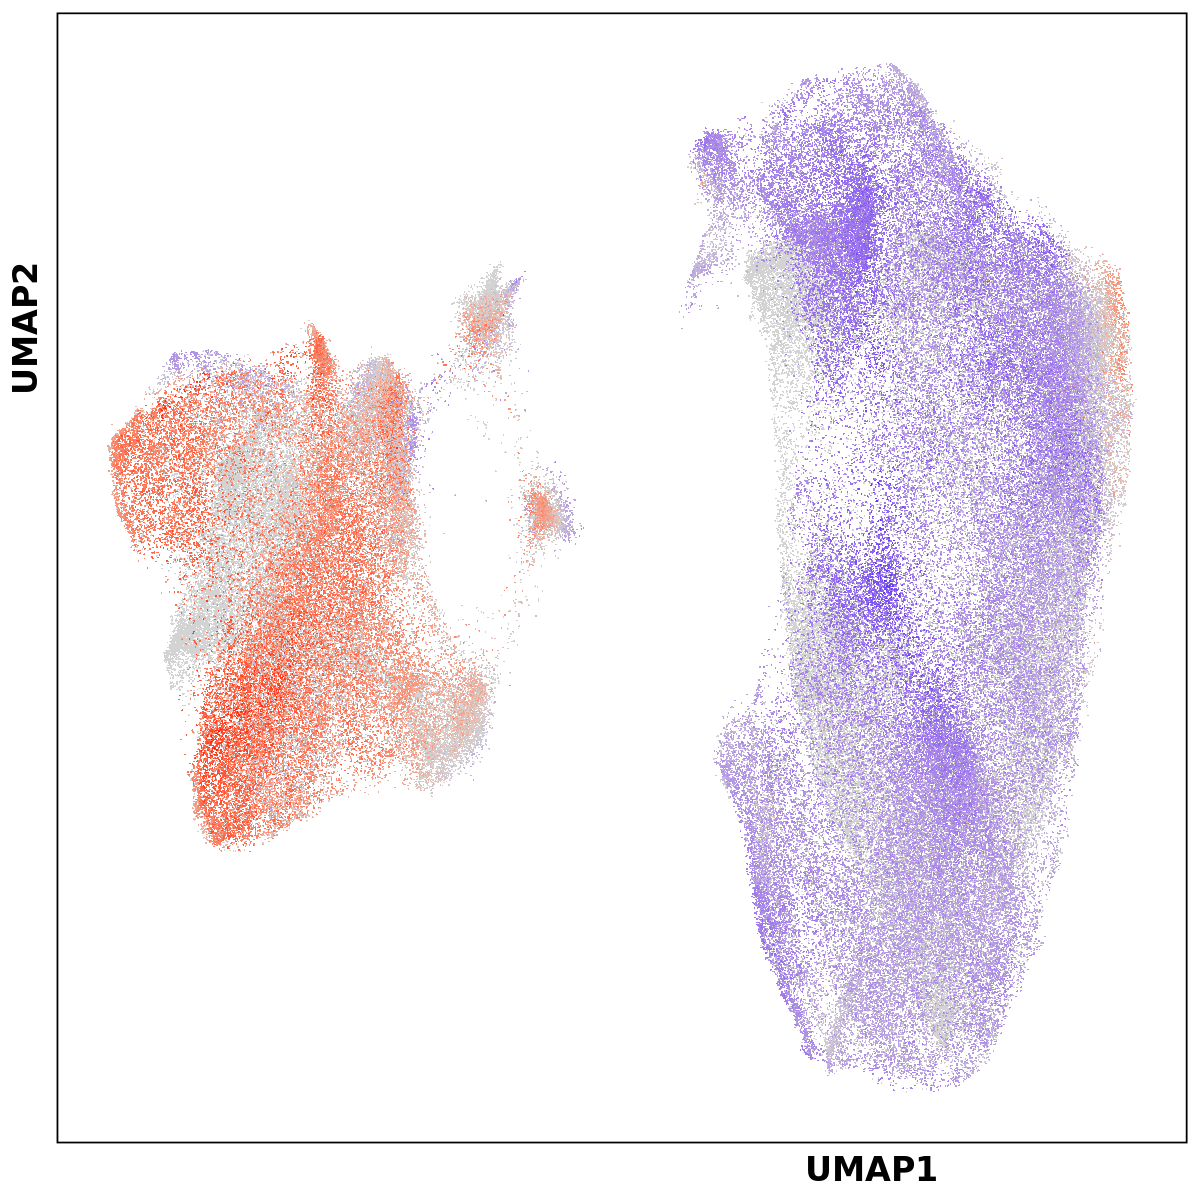

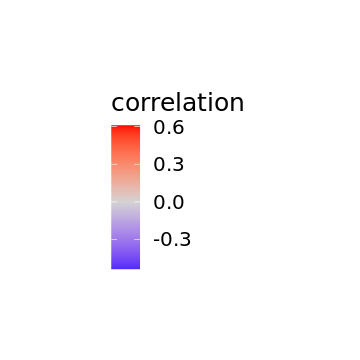

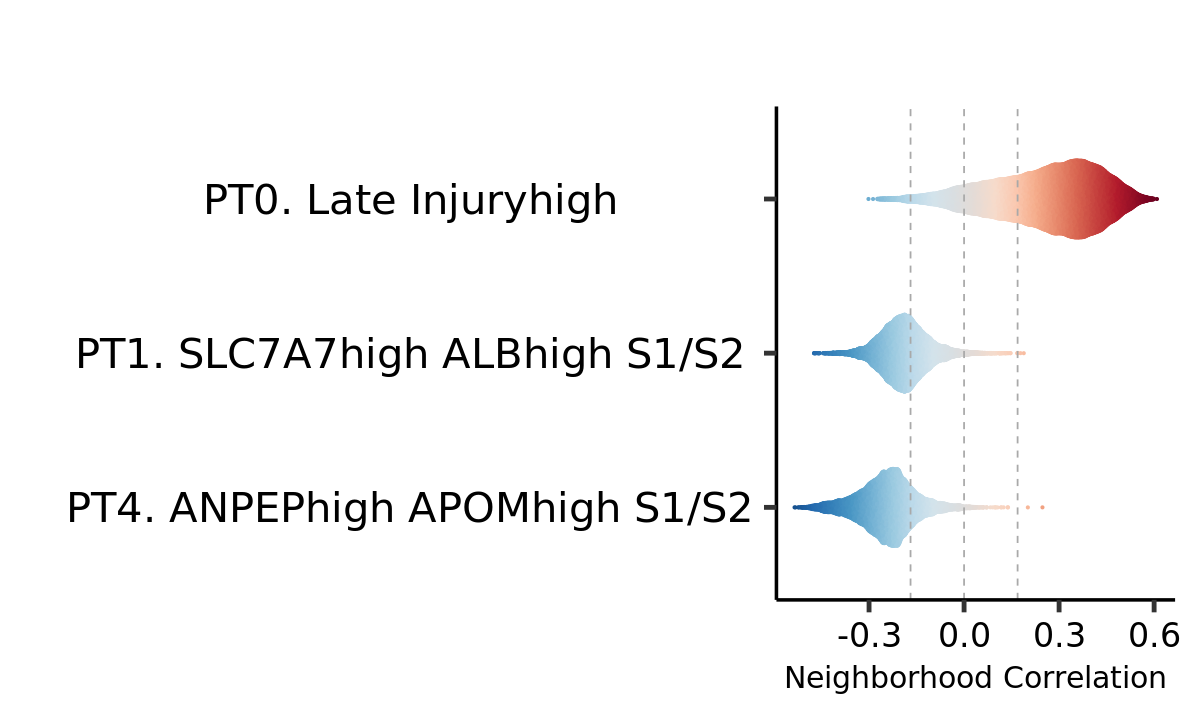

In [13]:
options(warn=-1)
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/chronicity/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/chronicity/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/chronicity/sc_conditional_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/chronicity/sc_conditional_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1

fdr_5 <- fdrs %>% filter(fdr < 0.05) %>% 
            mutate(fdr = round(fdr, 4)) %>% 
            filter(fdr == max(fdr)) %>% 
            pull(threshold)

tmp_meta <- meta %>% mutate(ifelse(abs(meta$ncorr) > fdr_5, ncorr, NA))
tmp_meta <- cbind(tmp_meta, umap)

fig.size(8, 8)
cna_umap <- ggplot() + 
      geom_point(data = pt_meta,
                aes(x = huwotUMAP1, y = huwotUMAP2), color = 'lightgrey', size = 0.75, stroke = 0.0001, shape = 20) + 
        geom_point(
              data = tmp_meta[sample(nrow(tmp_meta)),] %>% rename(correlation = ncorr), 
                  aes(x = huwotUMAP1, y = huwotUMAP2, color = correlation), size = 0.75, stroke = 0.0001, shape = 20) + 
              scale_color_gradient2(low = 'blue', mid = 'lightgray', high = 'red', na.value = "lightgrey") + 
             # labs(x="UMAP1", y="UMAP2", title = "Myeloid Chronicity: p = 2.00e-04") +
        theme_classic(base_size = 15) +
              theme(
                legend.position = "right",
                    #  plot.title = element_text(hjust = 0.5, 
                    #                            size = 18, 
                    #                            face = "bold"),
                      axis.title = element_text(hjust = 0.75, 
                                                size = 20, 
                                                face = "bold"), 
                      axis.text = element_blank(),
                      axis.line = element_blank(),
                      axis.ticks = element_blank(),
                      panel.border = element_rect(colour = "black", fill=NA, size=1)
            ) +
                labs(x = "UMAP1", y = "UMAP2") + 
            theme(text=element_text(family="Arial")) 

umap_legend <- cowplot::get_legend(cna_umap)
cna_umap <- cna_umap + theme(legend.position = "none")
umap_legend <- cowplot::plot_grid(umap_legend)
fig.size(10, 10)
cna_umap
fig.size(3, 3)
umap_legend

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure4/pt_sc_cna_umap.png",
       cna_umap,
       base_height = 10,
       base_width = 10)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure4/pt_sc_cna_umap_legend.png",
       umap_legend,
       base_height = 3,
       base_width = 3)

pos_fdr_thresh <- fdr_5
neg_fdr_thresh <- -1 * fdr_5

interval <- c(-max(abs(meta$ncorr)), max(abs(meta$ncorr)))


myPalette <- colorRampPalette(c(RColorBrewer::brewer.pal(11, "RdBu")[11:7], "#DCDCDC", RColorBrewer::brewer.pal(11, "RdBu")[5:1]))
fig.size(4, 6)
subset <- c('PT1. SLC7A7high ALBhigh S1/S2', 'PT4. ANPEPhigh APOMhigh S1/S2', 'PT0. Late Injuryhigh')

violin_plot <- ggplot(meta %>% filter(final_annotation %in% subset), aes(y = reorder(final_annotation, ncorr), x = ncorr)) +
                ggbeeswarm::geom_quasirandom(aes(color = ncorr), width = 0.25, size = 0.5) +
                                geom_vline(xintercept = neg_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                                geom_vline(xintercept = pos_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                                geom_vline(xintercept = 0, linetype = "dashed", color = "darkgrey") +
                                scale_colour_gradientn(colours = myPalette(20), limits = interval) +
                                labs( x= "Neighborhood Correlation", y = "", title = "") +
                                theme_classic(base_size = 30) +
                                theme(text=element_text(family="Arial"),
                                    legend.position = "none",
                                    panel.grid = element_blank(),
                                    axis.text.x = element_text(color = "black", size = 20, hjust=0.5),
                                    axis.text.y = element_text(color = "black", size = 25, hjust=0.5),
                                    axis.title = element_text(size=18, hjust = 0.5),
                                    axis.line.x.bottom = element_line(color = 'black', linewidth = 1),
                                    axis.line.y.left   = element_line(color = 'black', linewidth = 1))

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure4/pt_sc_violin_plot.png",
       violin_plot,
       base_height = 6,
       base_width = 10)
fig.size(6, 10)
violin_plot
options(warn=0)

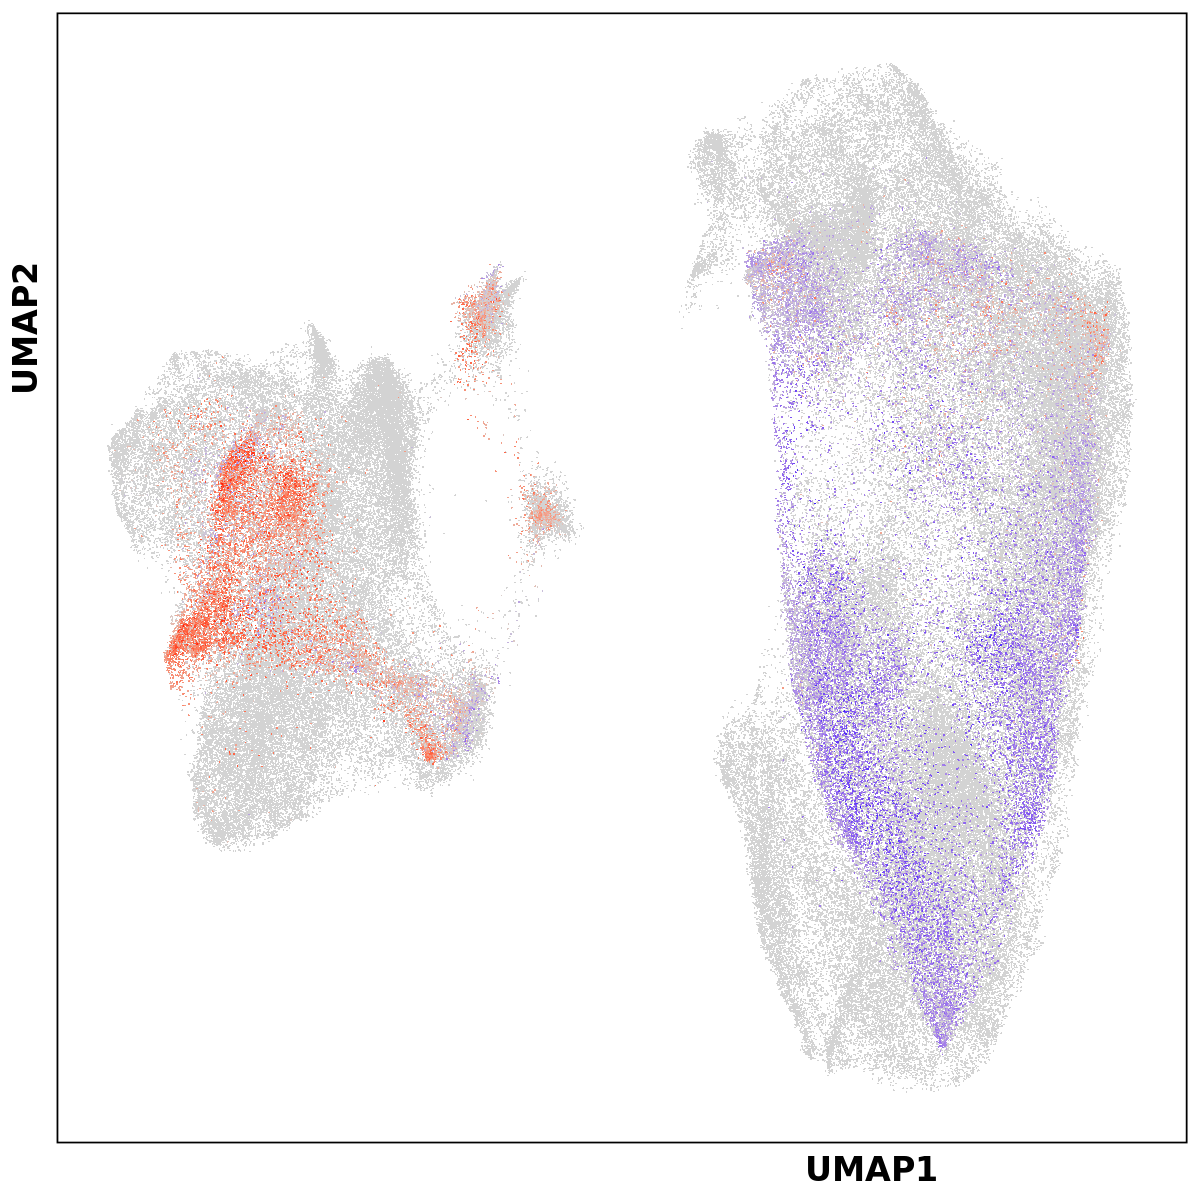

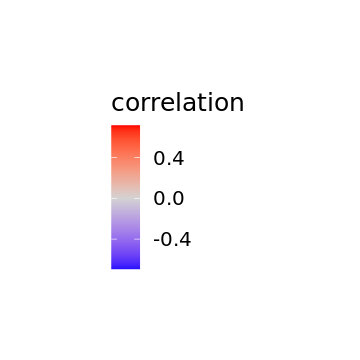

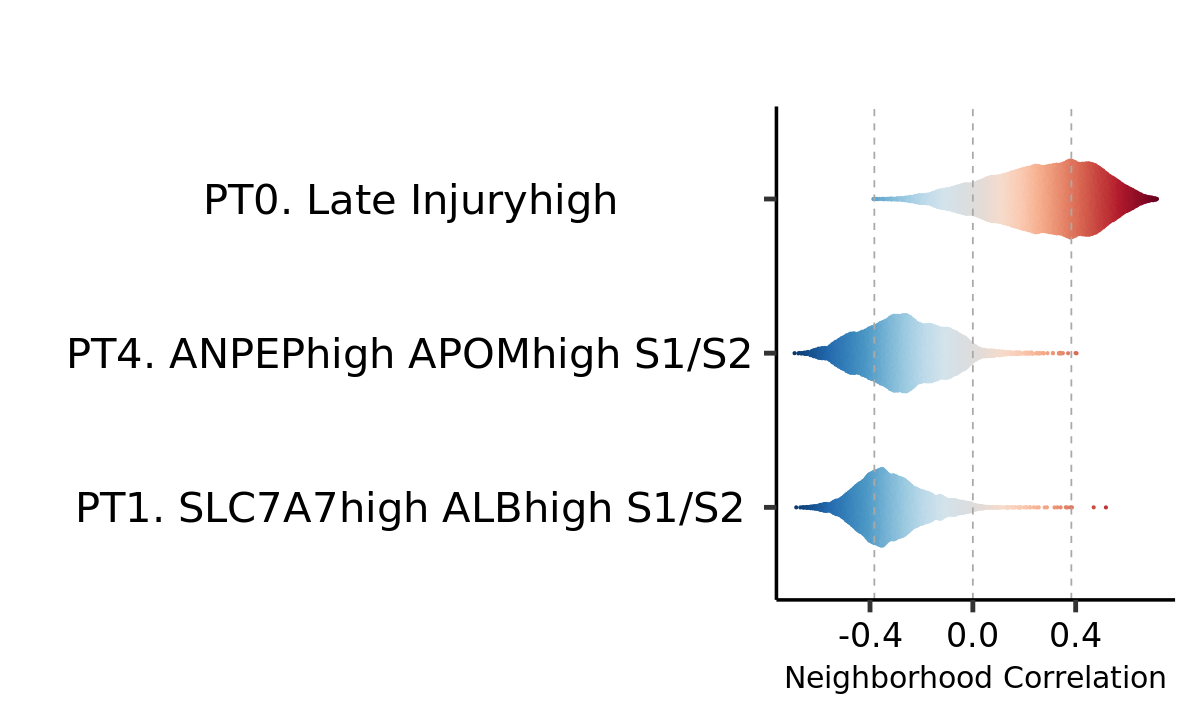

In [6]:
options(warn=-1)
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/chronicity/sn_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/chronicity/sn_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/chronicity/sn_conditional_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/chronicity/sn_conditional_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1

fdr_5 <- fdrs %>% filter(fdr < 0.05) %>% 
            mutate(fdr = round(fdr, 4)) %>% 
            filter(fdr == max(fdr)) %>% 
            pull(threshold)

tmp_meta <- meta %>% mutate(ifelse(abs(meta$ncorr) > fdr_5, ncorr, NA))
tmp_meta <- cbind(tmp_meta, umap)

fig.size(8, 8)
cna_umap <- ggplot() + 
      geom_point(data = pt_meta,
                aes(x = huwotUMAP1, y = huwotUMAP2), color = 'lightgrey', size = 0.75, stroke = 0.0001, shape = 20) + 
        geom_point(
              data = tmp_meta[sample(nrow(tmp_meta)),] %>% rename(correlation = ncorr), 
                  aes(x = huwotUMAP1, y = huwotUMAP2, color = correlation), size = 0.75, stroke = 0.0001, shape = 20) + 
              scale_color_gradient2(low = 'blue', mid = 'lightgray', high = 'red', na.value = "lightgrey") + 
             # labs(x="UMAP1", y="UMAP2", title = "Myeloid Chronicity: p = 2.00e-04") +
        theme_classic(base_size = 15) +
              theme(
                legend.position = "right",
                    #  plot.title = element_text(hjust = 0.5, 
                    #                            size = 18, 
                    #                            face = "bold"),
                      axis.title = element_text(hjust = 0.75, 
                                                size = 20, 
                                                face = "bold"), 
                      axis.text = element_blank(),
                      axis.line = element_blank(),
                      axis.ticks = element_blank(),
                      panel.border = element_rect(colour = "black", fill=NA, size=1)
            ) +
                labs(x = "UMAP1", y = "UMAP2") + 
            theme(text=element_text(family="Arial")) 

umap_legend <- cowplot::get_legend(cna_umap)
cna_umap <- cna_umap + theme(legend.position = "none")
umap_legend <- cowplot::plot_grid(umap_legend)
fig.size(10, 10)
cna_umap
fig.size(3, 3)
umap_legend

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/extended_data/figure3/pt_sn_cna_umap.png",
       cna_umap,
       base_height = 10,
       base_width = 10)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/extended_data/figure3/pt_sn_cna_umap_legend.png",
       umap_legend,
       base_height = 3,
       base_width = 3)

pos_fdr_thresh <- fdr_5
neg_fdr_thresh <- -1 * fdr_5

interval <- c(-max(abs(meta$ncorr)), max(abs(meta$ncorr)))


myPalette <- colorRampPalette(c(RColorBrewer::brewer.pal(11, "RdBu")[11:7], "#DCDCDC", RColorBrewer::brewer.pal(11, "RdBu")[5:1]))
fig.size(4, 6)
subset <- c('PT1. SLC7A7high ALBhigh S1/S2', 'PT4. ANPEPhigh APOMhigh S1/S2', 'PT0. Late Injuryhigh')

violin_plot <- ggplot(meta %>% filter(final_annotation %in% subset), aes(y = reorder(final_annotation, ncorr), x = ncorr)) +
                ggbeeswarm::geom_quasirandom(aes(color = ncorr), width = 0.25, size = 0.5) +
                                geom_vline(xintercept = neg_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                                geom_vline(xintercept = pos_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                                geom_vline(xintercept = 0, linetype = "dashed", color = "darkgrey") +
                                scale_colour_gradientn(colours = myPalette(20), limits = interval) +
                                labs( x= "Neighborhood Correlation", y = "", title = "") +
                                theme_classic(base_size = 30) +
                                theme(text=element_text(family="Arial"),
                                    legend.position = "none",
                                    panel.grid = element_blank(),
                                    axis.text.x = element_text(color = "black", size = 20, hjust=0.5),
                                    axis.text.y = element_text(color = "black", size = 25, hjust=0.5),
                                    axis.title = element_text(size=18, hjust = 0.5),
                                    axis.line.x.bottom = element_line(color = 'black', linewidth = 1),
                                    axis.line.y.left   = element_line(color = 'black', linewidth = 1))
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/extended_data/figure3/pt_sn_violin_plot.png",
       violin_plot,
       base_height = 6,
       base_width = 10)
fig.size(6, 10)
violin_plot
options(warn=0)

In [8]:
pt_norm <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/PT_qcd_norm_12072023.rds')

In [18]:
meta <- meta %>% 
            cbind(umap %>% rename(hUMAP1 = huwotUMAP1,
                                  hUMAP2 = huwotUMAP2))

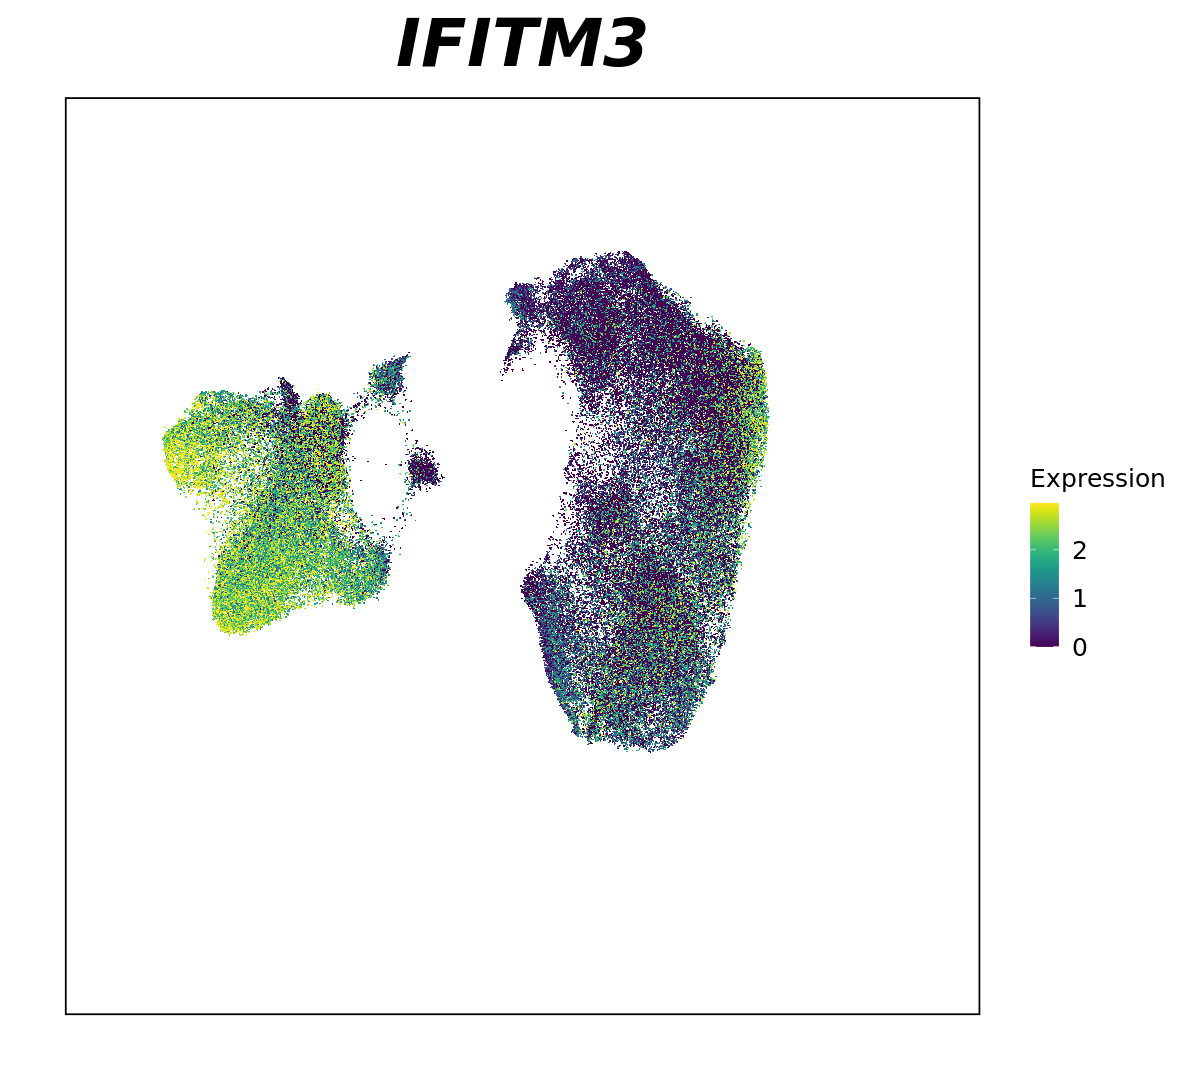

In [21]:
fig.size(9, 10)
p <- plot_shuffled_features(meta, 
                       pt_norm, "IFITM3", 
                       pct = 0.95, 
                       pt_size = 0.75) + 
                    theme(plot.title = element_text(size = 40),
                                    panel.border = element_rect(colour = "black", fill=NA, size=1)) +
                scale_x_continuous(limits = c(-12, 12)) +
                scale_y_continuous(limits = c(-8, 6))  + 
    theme(plot.title = element_text(size = 40),
          panel.border = element_rect(colour = "black", fill=NA, size=1),
          legend.text = element_text(size = 15),
          legend.title = element_text(size = 15))

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure4/pt_isg_plot.png",
       p,
       base_height = 9,
       base_width = 10)
p

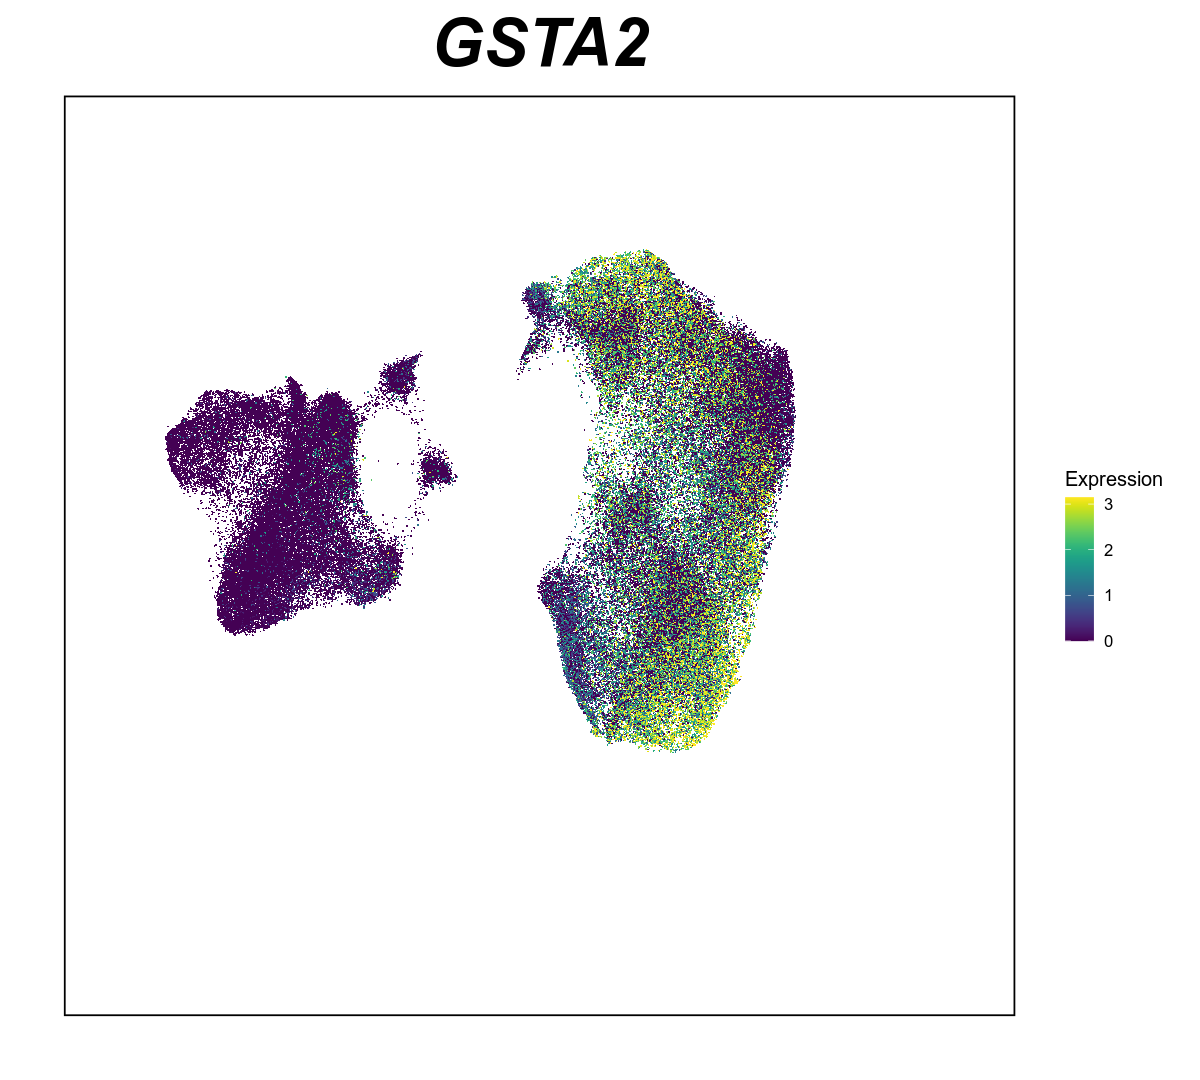

In [46]:
fig.size(9, 10)
plot_shuffled_features(meta, 
                       pt_norm, "GSTA2", 
                       pct = 0.95, 
                       pt_size = 0.75) + 
    theme(plot.title = element_text(size = 40),
                    panel.border = element_rect(colour = "black", fill=NA, size=1)) +
scale_x_continuous(limits = c(-12, 12)) +
scale_y_continuous(limits = c(-8, 6)) 

In [53]:
sc_meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/chronicity/sc_meta.csv')
sc_ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/chronicity/sc_conditional_ncorr.csv", header = FALSE)
sc_meta$ncorr <- sc_ncorr$V1
sn_meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/chronicity/sn_meta.csv')
sn_ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/chronicity/sn_conditional_ncorr.csv", header = FALSE)
sn_meta$ncorr <- sn_ncorr$V1

final_annotation <- data.frame(hres.0.4 = as.factor(seq(0, 7)),
                               final_annotation = c("PT0. Late Injuryhigh",
                                                    "PT1. SLC7A7high ALBhigh S1/S2",
                                                    "PT2. Low Quality",
                                                    "PT3. PCK1high DXCRhigh S2/S3",
                                                    "PT4. ANPEPhigh APOMhigh S1/S2",
                                                    "PT5. Late Injurylow S1/S2",
                                                    "PT6. PKHD1high SLC3A1high S2/S3",
                                                    "PT7. DTL"))

sc_meta <- left_join(sc_meta, final_annotation) %>% mutate(new_cluster_number = hres.0.4)
sn_meta <- left_join(sn_meta, final_annotation) %>% mutate(new_cluster_number = hres.0.4)

sc_summary <- sc_meta %>% 
                select(new_cluster_number, cell, ncorr) %>% 
                group_by(new_cluster_number) %>% 
                summarize(sc.ncorr.ci = paste0("(", round(mean(ncorr) - 1.96 * sd(ncorr) / sqrt(length(cell)), 3),
                                      ", ", round(mean(ncorr) + 1.96 * sd(ncorr) / sqrt(length(cell)), 3), ")"))
sn_summary <-  sn_meta %>% 
                select(new_cluster_number, cell, ncorr) %>% 
                group_by(new_cluster_number) %>% 
                summarize(sn.ncorr.ci = paste0("(", round(mean(ncorr) - 1.96 * sd(ncorr) / sqrt(length(cell)), 3),
                                      ", ", round(mean(ncorr) + 1.96 * sd(ncorr) / sqrt(length(cell)), 3), ")"))
summary <- sc_summary %>% left_join(sn_summary)
write.table(summary, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/pt_chronicity_corr_04152024.csv', 
              quote = FALSE, row.names = FALSE, sep = "\t")

Joining, by = "final_annotation"
Joining, by = "final_annotation"
Joining, by = "new_cluster_number"


### DE

In [4]:
de <- function(feature, df) {
    model_df <- df %>% select(feature, sample, First_biop, Responder_Status, 
                              Final_Chronicity, avg_count, avg_mt) %>% rename(Exp = feature)
    if (sum(model_df$Exp > 0) > 0.05 * nrow(model_df)) { 
        m_0 <- lm(Exp ~ log(avg_count) + avg_mt, data = model_df)
        m_1 <- lm(Exp ~ log(avg_count) + avg_mt + Final_Chronicity, data = model_df)
        ANNO <- anova(m_0, m_1)
        LRP <- ANNO[2,6]
        F <- ANNO[2,5]
        Beta <- summary(m_1)$coefficients['Final_Chronicity', 'Estimate']
        SE <- summary(m_1)$coefficients['Final_Chronicity', 'Std. Error']
        res <- c(gene = feature, LRP = LRP, F = F, Beta = Beta, SE = SE)
    }
    else {
        res <- c(gene = feature, LRP = NA, F = NA, Beta = NA, SE = NA)
    }
    return(res)
}

In [5]:
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/chronicity/sc_meta.csv')
pt_pb <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/PT_norm_pseudobulk_12072023.rds')

In [6]:
pt_pb <- pt_pb %>% 
                filter(sample %in% unique(meta$sample)) %>% 
                left_join(meta %>% 
                              select(sample, First_biop, Responder_Status, Final_Chronicity) %>% 
                              unique())

Joining, by = "sample"


In [7]:
de_out <- mclapply(colnames(pt_pb)[1:36601], de, pt_pb, mc.cores = 20)

In [8]:
de_df <- data.frame(do.call(rbind, de_out)) %>% mutate(LRP = as.numeric(LRP),
                                                       F = as.numeric(F),
                                                       Beta = as.numeric(Beta),
                                                       SE = as.numeric(SE))

In [9]:
saveRDS(de_df, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/PT_chronicity_differential_expression_03082024.rds')

In [39]:
de_df <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/PT_chronicity_differential_expression_03082024.rds')

In [40]:
de_df <- de_df %>% 
            na.omit() %>% 
            arrange(LRP) %>% 
            mutate(FDR = p.adjust(LRP, method = "BH")) 

In [44]:
de_df %>% filter(gene == "IFITM3")

gene,LRP,F,Beta,SE,FDR
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
IFITM3,0.002254472,9.691216,0.05602151,0.01799557,0.0101598


In [28]:
genes <- c("NNMT", "MMP7", "TIMP1", "ANXA2", "WFDC2", "S100A6", "MIOX",
           "MIOX", "FTL", "FABP1", "APOE", "GSTA2", "IFITM3")

Warning message:
“Removed 26903 rows containing missing values (`geom_text_repel()`).”
Warning message:
“ggrepel: 29 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


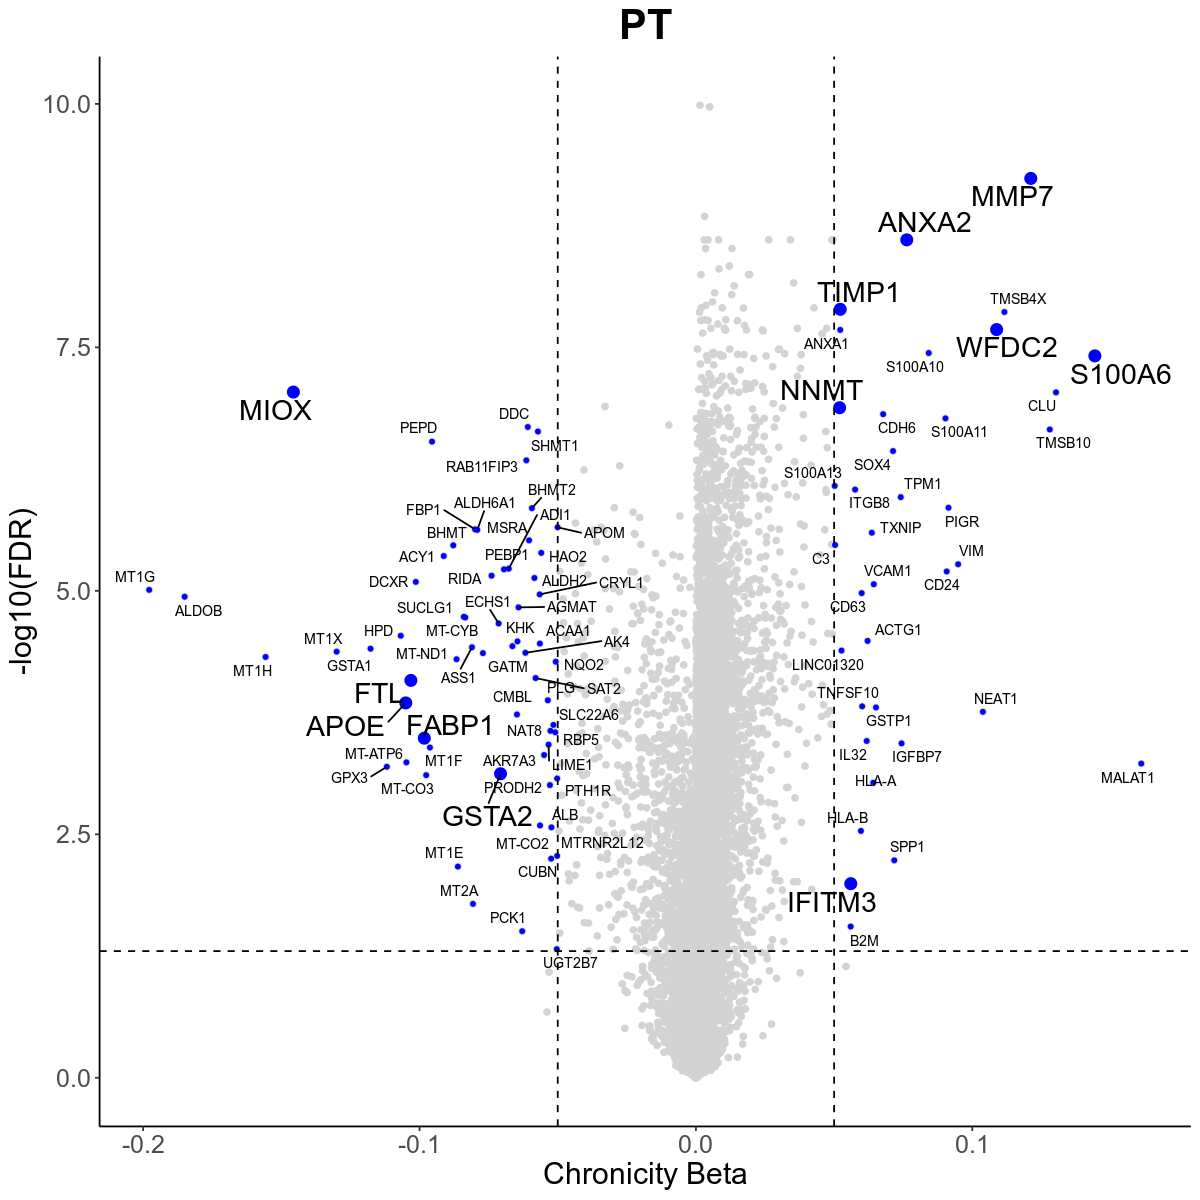

In [30]:
fig.size(10, 10)
ggplot(de_df,
                aes(x = Beta, y = -log10(FDR))) +
    geom_point(colour = 'lightgrey') + 
    geom_point(data = de_df %>% filter(FDR < 0.05 & abs(Beta) >= 0.05,
                                        ! gene %in% genes),
                   aes(x = Beta, y = -log10(FDR)),  color = "blue", size = 1) +
    geom_point(data = de_df %>% filter(gene %in% genes),
                   aes(x = Beta, y = -log10(FDR)),  color = "blue", size = 3)  + 
    geom_vline(xintercept = c(-0.05, 0.05), linetype = "dashed") + 
    geom_hline(yintercept = -log10(0.05), linetype = "dashed") + 
    theme_classic() + 
    theme(legend.position = "none",
          axis.text = element_text(size = 15),
          axis.title = element_text(size = 18),
          plot.title = element_text(size = 25, hjust = 0.5, face = "bold")) +
    ggrepel::geom_text_repel(data = de_df %>% 
                                     mutate(label = ifelse(FDR < 0.05 & abs(Beta) >= 0.05 | 
                                                           gene %in% genes, gene, NA),
                                            label_size = ifelse(gene %in% genes, 6 , 3)),
                                     aes(x = Beta, y = -log10(FDR), 
                                         size = label_size, label = label)
            , color = "black") +
    scale_size_identity() + 
    labs(x = "Chronicity Beta", y = "-log10(FDR)", title = "PT")

In [ ]:
fig.size(10,10)
p <- plot_shuffled_features(meta, 
                       qcd_norm, 
                       "IFITM3", pct = 0.95, pt_size = 0.75)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure4/myeloid_isg_plot.png",
       violin_plot,
       base_height = 10,
       base_width = 10)

### ISG Score

In [3]:
genes <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/pseudobulk_de/isg_genes.rds')
pt_pb <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/pseudobulk_de/PT_norm_pseudobulk_12072023.rds')

In [4]:
chron_isg_pb <- pt_pb %>% 
                    mutate(individual = str_remove(sample, "AMPSLEkid_cells_")) %>% 
                    select(c(genes, individual)) %>% 
                    left_join(clinical %>% select(individual, Final_Chronicity)) 
for (i in genes) {
    chron_isg_pb[, i] <- as.numeric(chron_isg_pb[, i])
}
chron_isg_pb$isg_score <- rowMeans(chron_isg_pb[, genes])

Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(genes)

  # Now:
  data %>% select(all_of(genes))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”
Joining, by = "individual"


In [5]:
cor.test(chron_isg_pb$Final_Chronicity, chron_isg_pb$isg_score)


	Pearson's product-moment correlation

data:  chron_isg_pb$Final_Chronicity and chron_isg_pb$isg_score
t = 2.6917, df = 139, p-value = 0.007983
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.05945355 0.37412439
sample estimates:
      cor 
0.2225781 


## ACTIVITY

In [4]:
meta <- sc_meta %>% select(-c(colnames(sc_meta[grep('hPC-', colnames(sc_meta))]), 
                          colnames(sc_meta[grep('huwotUMAP', colnames(sc_meta))])))
harmony <- sc_meta %>% select(colnames(sc_meta)[grep('hPC-', colnames(sc_meta))])

umap <- sc_meta %>% select(c(huwotUMAP1, huwotUMAP2))

ind <- c(1:nrow(meta))[!is.na(meta$Final_Activity)]
meta <- meta[ind, ]
harmony <- harmony[ind, ]
umap <- umap[ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex <- as.numeric(as.factor(meta$Sex))
meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")

write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/activity/sc_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/activity/sc_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/activity/sc_umap.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "Responder.Status"


In [5]:
meta <- sn_meta %>% select(-c(colnames(sn_meta[grep('hPC-', colnames(sn_meta))]), 
                          colnames(sn_meta[grep('huwotUMAP', colnames(sn_meta))])))

harmony <- sn_meta %>% select(colnames(sn_meta)[grep('hPC-', colnames(sn_meta))])

umap <- sn_meta %>% select(c(huwotUMAP1, huwotUMAP2))

ind <- c(1:nrow(meta))[!is.na(meta$Final_Activity)]
meta <- meta[ind, ]
harmony <- harmony[ind, ]
umap <- umap[ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex <- as.numeric(as.factor(meta$Sex))
meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")

write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/activity/sn_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/activity/sn_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/activity/sn_umap.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "Responder.Status"


## ISN

In [25]:
meta <- sc_meta %>% select(-c(colnames(sc_meta[grep('hPC-', colnames(sc_meta))]), 
                          colnames(sc_meta[grep('huwotUMAP', colnames(sc_meta))])))
harmony <- sc_meta %>% select(colnames(sc_meta)[grep('hPC-', colnames(sc_meta))])

umap <- sc_meta %>% select(c(huwotUMAP1, huwotUMAP2))

ind <- c(1:nrow(meta))[!is.na(meta$Final_ISN)]

meta <- meta[ind, ]
harmony <- harmony[ind, ]
umap <- umap[ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex <- as.numeric(as.factor(meta$Sex))
meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")
write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/ISN/sc_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/ISN/sc_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/ISN/sc_umap.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "Responder.Status"


In [26]:
meta <- sn_meta %>% select(-c(colnames(sn_meta[grep('hPC-', colnames(sn_meta))]), 
                          colnames(sn_meta[grep('huwotUMAP', colnames(sn_meta))])))
harmony <- sn_meta %>% select(colnames(sn_meta)[grep('hPC-', colnames(sn_meta))])

umap <- sn_meta %>% select(c(huwotUMAP1, huwotUMAP2))

ind <- c(1:nrow(meta))[!is.na(meta$Final_ISN)]

meta <- meta[ind, ]
harmony <- harmony[ind, ]
umap <- umap[ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex <- as.numeric(as.factor(meta$Sex))
meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")
write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/ISN/sn_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/ISN/sn_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/PT/ISN/sn_umap.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "Responder.Status"
